# 22. Corporate Credit Risk, Market Pricing and Structured Credit

In [1]:
from pathlib import Path
import hashlib
import json

import duckdb
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cycler import cycler
from IPython.display import display
from scipy.optimize import brentq
from scipy.special import logit
from scipy.stats import norm, spearmanr, t as student_t
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss, roc_auc_score
from sklearn.preprocessing import SplineTransformer, StandardScaler
from statsmodels.duration.hazard_regression import PHReg

from quantfinlab.dataio import read_equity_history
from quantfinlab.fixed_income import discount_factor_from_rate
from quantfinlab.fundamentals import (
    annual_change, annual_growth, cash_to_assets, cfo_to_debt,
    classify_duration_facts, debt_to_assets, fcf_to_assets, free_cash_flow,
    monthly_statement_values, operating_margin, reconstruct_quarters,
    return_on_assets, safe_ratio, select_filing_facts,
    statement_reconstruction_checks, total_accruals, total_debt,
    working_capital)
from quantfinlab.portfolio.covariance import (
    ledoit_wolf_covariance, make_psd, oas_covariance)
from quantfinlab.risk import hist_var_es

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 130)
palette = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7",
           "#9614fa", "#DC143C", "#7BC8F6", "#0072B2", "#04D8B2",
           "#800080", "#FF8072"]
plt.rcParams["axes.prop_cycle"] = cycler(color=palette)
plt.rcParams.update({"figure.figsize": (6, 3), "figure.dpi": 200, "savefig.dpi": 300,
                     "axes.grid": True, "grid.alpha": 0.20, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.titlesize": 12,
                     "axes.labelsize": 12, "xtick.labelsize": 9,
                     "ytick.labelsize": 9, "legend.fontsize": 7})
rng = np.random.default_rng(22)

In [2]:
ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA = ROOT / "data"
WORK = ROOT / "workspace" / "credit_risk_cache"

SEC_PATH = DATA / "sec_credit.parquet"
MARKET_PATH = DATA / "sp500_market_data.parquet"
CURVE_PATH = DATA / "treasury_credit_curves.parquet"
FED_PATH = DATA / "fed_credit.parquet"
CMDI_PATH = DATA / "nyfed_cmdi.parquet"
FINRA_PATH = DATA / "finra_credit_market.parquet"
STRUCTURED_PRICE_PATH = DATA / "finra_structured_pricing.parquet"
STRUCTURED_ACTIVITY_PATH = DATA / "finra_structured_activity.parquet"
ERRATA_PATH = DATA / "finra_structured_errata.parquet"
MACRO_PATH = DATA / "us_macro_factors.csv"

required_files = [SEC_PATH, MARKET_PATH, CURVE_PATH, FED_PATH, CMDI_PATH, FINRA_PATH,
                  STRUCTURED_PRICE_PATH, STRUCTURED_ACTIVITY_PATH, ERRATA_PATH, MACRO_PATH]
assert all(path.exists() for path in required_files)

sample_start = pd.Timestamp("2012-01-01")
oos_start = pd.Timestamp("2019-01-01")
horizons = (3, 6, 12, 24)
R = 0.40
LGD = 1.0 - R
strict_event = "is_registrant_bankruptcy_event"
broad_event = "is_financial_obligation_trigger"
model_version = "multi-horizon-v3"

stamp = f"{SEC_PATH.stat().st_size}:{SEC_PATH.stat().st_mtime_ns}"
source_key = hashlib.sha256(stamp.encode()).hexdigest()[:10]
cache = WORK / source_key
cache.mkdir(parents=True, exist_ok=True)
config = {"sample_start": str(sample_start.date()), "oos_start": str(oos_start.date()),
          "horizons": horizons, "recovery": R, "strict_event": strict_event,
          "broad_event": broad_event, "source_key": source_key,
          "model_version": model_version, "seed": 22}
run_hash = hashlib.sha256(json.dumps(config, sort_keys=True).encode()).hexdigest()[:12]

con = duckdb.connect()
con.execute(f"CREATE VIEW sec AS SELECT * FROM read_parquet('{SEC_PATH.as_posix()}')")
filings = con.execute("""
    SELECT record_type, cik, ticker, submission_tickers, entity_name, sec_sic,
           sec_industry, entity_type, mapping_valid_from,
           mapping_valid_to, accepted_at, filed_date, report_date, form_type,
           accession, form_items, bankruptcy_scope, bankruptcy_review_note,
           is_bankruptcy_or_receivership, is_registrant_bankruptcy_event,
           is_financial_obligation_trigger, is_exit_or_disposal,
           is_material_impairment, is_delisting_or_listing_failure,
           is_nonreliance, is_late_filing, is_deregistration
    FROM sec
    WHERE record_type = 'filing'
""").fetchdf()
for name in ["mapping_valid_from", "mapping_valid_to", "accepted_at", "filed_date", "report_date"]:
    filings[name] = pd.to_datetime(filings[name])
last_month = filings["accepted_at"].max().to_period("M").to_timestamp("M")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [3]:
strict_scopes = {"registrant_bankruptcy_petition", "registrant_receivership"}
strict_rows = filings[filings[strict_event]]
item_103 = filings[filings["is_bankruptcy_or_receivership"]]
item_204 = filings[filings[broad_event]]
financial_sic = filings["sec_sic"].between(6000, 6799)

assert filings["record_type"].eq("filing").all()
assert filings["cik"].notna().all() and filings["cik"].gt(0).all()
assert filings["accepted_at"].notna().all()
assert not filings.duplicated(["cik", "accession"]).any()
assert not financial_sic.any()
assert strict_rows["bankruptcy_scope"].isin(strict_scopes).all()
assert not strict_rows["bankruptcy_scope"].eq("unreviewed").any()
assert strict_rows["is_bankruptcy_or_receivership"].all()

event_audit = pd.DataFrame({
    "filing rows": [len(filings), len(item_103), len(strict_rows), len(item_204)],
    "issuers": [filings["cik"].nunique(), item_103["cik"].nunique(),
                strict_rows["cik"].nunique(), item_204["cik"].nunique()]},
    index=["All filing metadata", "Raw 8-K Item 1.03", "Reviewed registrant event",
           "8-K Item 2.04"])
assert len(strict_rows) >= 477 and strict_rows["cik"].nunique() >= 386
display(event_audit)

,filing rows,issuers
All filing metadata,1057847,8000
Raw 8-K Item 1.03,1212,636
Reviewed registrant event,477,386
8-K Item 2.04,1855,1130


In [4]:
periodic_forms = ["10-K", "10-K/A", "10-Q", "10-Q/A"]
annual_forms = ["10-K", "10-K/A"]
periodic = filings[filings["form_type"].isin(periodic_forms)]

survival = periodic.groupby("cik").agg(
    first_periodic=("accepted_at", "min"), last_periodic=("accepted_at", "max"),
    n_periodic=("accession", "size"), entity_name=("entity_name", "last"),
    ticker=("ticker", "last"), sec_sic=("sec_sic", "last"),
    sec_industry=("sec_industry", "last"))
survival["n_10k"] = periodic[periodic["form_type"].isin(annual_forms)].groupby("cik").size()
survival["last_observed"] = filings.groupby("cik")["accepted_at"].max()
survival["strict_date"] = strict_rows.groupby("cik")["accepted_at"].min()
survival["broad_date"] = filings[
    filings[strict_event] | filings[broad_event]].groupby("cik")["accepted_at"].min()
survival["history_years"] = (
    survival["last_periodic"] - survival["first_periodic"]).dt.days.div(365.25)
survival = survival.query("n_10k >= 1 and n_periodic >= 5 and history_years >= 1").reset_index()
survival["active_start"] = survival["first_periodic"].clip(lower=sample_start)
survival["active_end"] = survival[["last_observed", "strict_date"]].min(axis=1)

year_ends = pd.date_range(sample_start, filings["accepted_at"].max(), freq="YE")
annual_rows = []
for date in year_ends:
    active = survival["active_start"].le(date) & survival["active_end"].gt(date)
    annual_rows.append({
        "year": date.year,
        "active_issuers": int(active.sum()),
        "strict_events": int(survival["strict_date"].dt.year.eq(date.year).sum()),
        "broad_events": int(survival["broad_date"].dt.year.eq(date.year).sum())
    })
annual_incidence = pd.DataFrame(annual_rows).set_index("year")
annual_incidence["strict_per_1000"] = 1000 * annual_incidence["strict_events"].div(
    annual_incidence["active_issuers"])
assert survival["strict_date"].lt(oos_start).sum() >= 100

In [5]:
credit_concepts = {
    "duration": {
        "revenue": ("us-gaap:RevenueFromContractWithCustomerExcludingAssessedTax",
                    "us-gaap:Revenues", "us-gaap:SalesRevenueNet"),
        "operating_income": ("us-gaap:OperatingIncomeLoss",),
        "net_income": ("us-gaap:NetIncomeLoss", "us-gaap:ProfitLoss"),
        "interest_expense": ("us-gaap:InterestExpense", "us-gaap:InterestExpenseNonoperating",
                             "us-gaap:InterestExpenseDebt"),
        "cfo": ("us-gaap:NetCashProvidedByUsedInOperatingActivities",
                "us-gaap:NetCashProvidedByUsedInOperatingActivitiesContinuingOperations"),
        "capex": ("us-gaap:PaymentsToAcquirePropertyPlantAndEquipment",
                  "us-gaap:PaymentsToAcquireProductiveAssets"),
        "depreciation": ("us-gaap:DepreciationDepletionAndAmortization", "us-gaap:Depreciation"),
        "interest_paid": ("us-gaap:InterestPaidNet",),
        "debt_repaid": ("us-gaap:RepaymentsOfLongTermDebt",),
        "debt_issued": ("us-gaap:ProceedsFromIssuanceOfLongTermDebt",),
        "restructuring_charge": ("us-gaap:RestructuringCharges",),
        "impairment_charge": ("us-gaap:AssetImpairmentCharges", "us-gaap:GoodwillImpairmentLoss",
                              "us-gaap:TangibleAssetImpairmentCharges")},
    "instant": {
        "cash": ("us-gaap:CashAndCashEquivalentsAtCarryingValue",
                 "us-gaap:CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents"),
        "short_investments": ("us-gaap:ShortTermInvestments", "us-gaap:MarketableSecuritiesCurrent"),
        "receivables": ("us-gaap:AccountsReceivableNetCurrent",),
        "inventory": ("us-gaap:InventoryNet",),
        "current_assets": ("us-gaap:AssetsCurrent",),
        "total_assets": ("us-gaap:Assets",),
        "current_liabilities": ("us-gaap:LiabilitiesCurrent",),
        "total_liabilities": ("us-gaap:Liabilities",),
        "common_equity": ("us-gaap:StockholdersEquity",),
        "retained_earnings": ("us-gaap:RetainedEarningsAccumulatedDeficit",),
        "total_debt_reported": ("us-gaap:DebtLongtermAndShorttermCombinedAmount",
                                "us-gaap:LongTermDebt"),
        "long_term_debt_noncurrent": ("us-gaap:LongTermDebtNoncurrent",),
        "debt_current": ("us-gaap:DebtCurrent", "us-gaap:LongTermDebtCurrent",
                         "us-gaap:LongTermDebtAndCapitalLeaseObligationsCurrent"),
        "short_term_borrowings": ("us-gaap:ShortTermBorrowings", "us-gaap:CommercialPaper"),
        "operating_lease_current": ("us-gaap:OperatingLeaseLiabilityCurrent",),
        "operating_lease_noncurrent": ("us-gaap:OperatingLeaseLiabilityNoncurrent",),
        "credit_available": ("us-gaap:LineOfCreditFacilityRemainingBorrowingCapacity",),
        "credit_drawn": ("us-gaap:LineOfCreditFacilityAmountOutstanding",),
        "debt_due_1y": ("us-gaap:LongTermDebtMaturitiesRepaymentsOfPrincipalInNextTwelveMonths",),
        "debt_due_2y": ("us-gaap:LongTermDebtMaturitiesRepaymentsOfPrincipalInYearTwo",),
        "debt_due_3y": ("us-gaap:LongTermDebtMaturitiesRepaymentsOfPrincipalInYearThree",),
        "debt_due_4y": ("us-gaap:LongTermDebtMaturitiesRepaymentsOfPrincipalInYearFour",),
        "debt_due_5y": ("us-gaap:LongTermDebtMaturitiesRepaymentsOfPrincipalInYearFive",),
        "debt_due_after_5y": ("us-gaap:LongTermDebtMaturitiesRepaymentsOfPrincipalAfterYearFive",)}}

concepts = [concept for section in credit_concepts.values()
            for choices in section.values() for concept in choices]
con.register("selected_concepts", pd.DataFrame({"concept": concepts}))

def read_credit_facts(ciks):
    con.register("selected_ciks", pd.DataFrame({"cik": pd.Series(ciks, dtype="int64")}))
    facts = con.execute("""
        SELECT s.cik, s.concept, s.value, s.unit, s.period_type, s.period_start,
               s.period_end, s.fiscal_year, s.fiscal_period, s.filed_date,
               s.accepted_at, s.form_type, s.accession, s.filing_version
        FROM sec s
        JOIN selected_concepts c USING (concept)
        JOIN selected_ciks i USING (cik)
        WHERE s.record_type = 'fact'
          AND s.form_type IN ('10-Q', '10-Q/A', '10-K', '10-K/A')
          AND s.period_end >= DATE '2009-01-01'
    """).fetchdf()
    facts["filed_date"] = pd.to_datetime(facts["accepted_at"])
    return facts

fact_coverage = con.execute("""
    SELECT credit_group, count(*) AS fact_rows, count(DISTINCT cik) AS issuers
    FROM sec s JOIN selected_concepts c USING (concept)
    WHERE record_type = 'fact' AND period_end >= DATE '2009-01-01'
    GROUP BY credit_group ORDER BY fact_rows DESC
""").fetchdf()

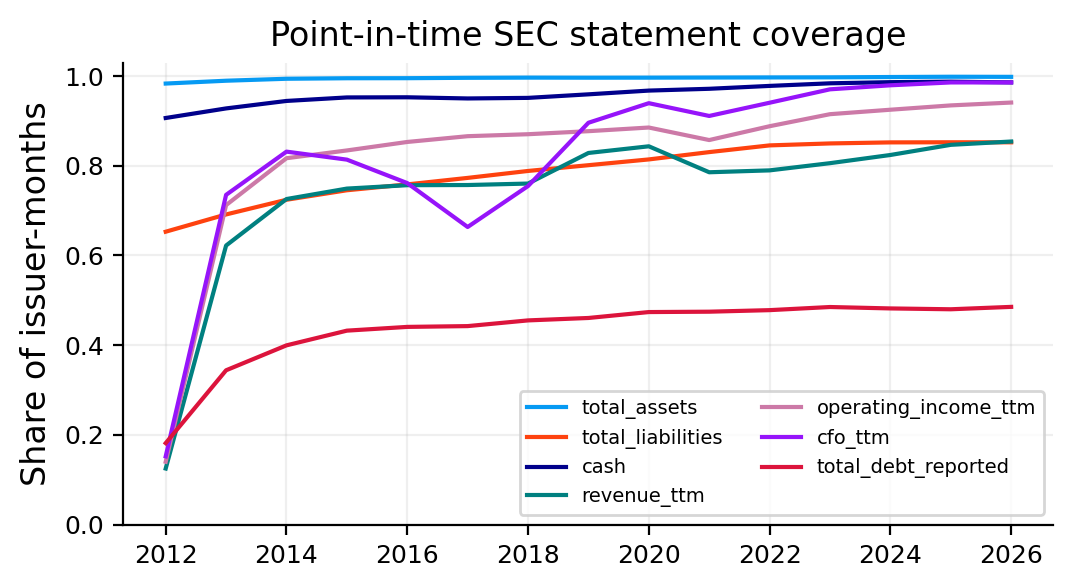

In [6]:
months = pd.date_range(sample_start + pd.offsets.MonthEnd(0), last_month, freq="ME")
statement_months = pd.MultiIndex.from_product(
    [months, survival["cik"]], names=["decision_date", "cik"]).to_frame(index=False)
statement_months = statement_months.merge(
    survival[["cik", "first_periodic", "last_periodic", "strict_date"]], on="cik", how="left")
statement_months["statement_end"] = statement_months[["last_periodic", "strict_date"]].min(axis=1)
statement_months = statement_months[
    statement_months["decision_date"].gt(statement_months["first_periodic"])
    & statement_months["decision_date"].lt(statement_months["statement_end"])
][["decision_date", "cik"]].reset_index(drop=True)

accounting_path = cache / "accounting_monthly.parquet"
if accounting_path.exists():
    accounting = pd.read_parquet(accounting_path)
else:
    batch_paths = []
    for batch, first in enumerate(range(0, len(survival), 1000)):
        batch_path = cache / f"accounting_batch_{batch:02d}.parquet"
        batch_paths.append(batch_path)
        if batch_path.exists():
            continue
        ciks = survival.iloc[first : first + 1000]["cik"]
        facts = read_credit_facts(ciks)
        classified = classify_duration_facts(facts, concepts=credit_concepts)
        monthly = statement_months[statement_months["cik"].isin(ciks)]
        values = monthly_statement_values(classified, monthly).dropna(axis=1, how="all")
        instant_fields = set(credit_concepts["instant"])
        keep = [name for name in values if (
            name in {"cik", "decision_date", "filed_date", "latest_quarter_end",
                     "latest_duration_end", "latest_balance_end", "latest_period_end"}
            or name in instant_fields or name.endswith(("_ttm", "_ttm_yoy", "_ttm_method")))]
        values[keep].to_parquet(batch_path, index=False)
    accounting = pd.concat([pd.read_parquet(path) for path in batch_paths], ignore_index=True)
    accounting.to_parquet(accounting_path, index=False)

audit_ciks = survival.sort_values("cik").head(100)["cik"]
audit_facts = classify_duration_facts(read_credit_facts(audit_ciks), concepts=credit_concepts)
known = select_filing_facts(audit_facts, decision_date=oos_start)
_, quarter_candidates = reconstruct_quarters(known)
checks = statement_reconstruction_checks(
    quarter_candidates, accounting,
    coverage_fields=("revenue_ttm", "operating_income_ttm", "net_income_ttm",
                     "cfo_ttm", "total_assets", "common_equity"))
assert int(checks["summary"].loc["point-in-time violations", "value"]) == 0

coverage_fields = ["total_assets", "total_liabilities", "cash", "revenue_ttm",
                   "operating_income_ttm", "cfo_ttm", "total_debt_reported"]
accounting_coverage = accounting.assign(year=accounting["decision_date"].dt.year).groupby("year")[
    coverage_fields].agg(lambda x: x.notna().mean())
accounting_coverage.plot()
plt.title("Point-in-time SEC statement coverage")
plt.ylabel("Share of issuer-months")
plt.xlabel("")
plt.ylim(0, 1.03)
plt.legend(ncol=2)
plt.show()

In [7]:
credit = pd.MultiIndex.from_product(
    [months, survival["cik"]], names=["decision_date", "cik"]).to_frame(index=False)
credit = credit.merge(
    survival[["cik", "first_periodic", "last_observed", "strict_date"]], on="cik", how="left")
credit["active_end"] = credit[["last_observed", "strict_date"]].min(axis=1)
credit = credit[
    credit["decision_date"].gt(credit["first_periodic"])
    & credit["decision_date"].lt(credit["active_end"])
][["decision_date", "cik"]]
credit = credit.merge(accounting, on=["decision_date", "cik"], how="left")
statement_columns = [name for name in accounting if name not in {"decision_date", "cik"}]
credit[statement_columns] = credit.groupby("cik", sort=False)[statement_columns].ffill()
credit = credit.merge(survival, on="cik", how="left").sort_values(
    ["cik", "decision_date"]).reset_index(drop=True)

expected = [*credit_concepts["instant"],
            *[f"{name}_ttm" for name in credit_concepts["duration"]]]
missing = [name for name in expected if name not in credit]
credit = credit.reindex(columns=[*credit.columns, *missing])

short_debt = credit["debt_current"].combine_first(credit["short_term_borrowings"])
long_debt = credit["long_term_debt_noncurrent"]
debt = total_debt(credit["total_debt_reported"], long_debt,
                  credit["debt_current"], credit["short_term_borrowings"])
long_debt = long_debt.combine_first((debt - short_debt).where(debt.gt(short_debt)))
debt = total_debt(credit["total_debt_reported"], long_debt,
                  credit["debt_current"], credit["short_term_borrowings"])

levels = pd.DataFrame({
    "short_debt": short_debt,
    "long_debt": long_debt,
    "debt": debt,
    "lease_debt": credit[["operating_lease_current", "operating_lease_noncurrent"]].sum(
        axis=1, min_count=2),
    "wc": working_capital(credit["current_assets"], credit["current_liabilities"]),
    "fcf": free_cash_flow(credit["cfo_ttm"], credit["capex_ttm"]),
    "ebitda": (credit["operating_income_ttm"] + credit["depreciation_ttm"]).where(
        credit[["operating_income_ttm", "depreciation_ttm"]].notna().all(axis=1)),
    "statement_age": (credit["decision_date"] - credit["filed_date"]).dt.days.div(30.4375)
})
levels["log_assets"] = np.log(credit["total_assets"].where(credit["total_assets"].gt(0)))
levels["invalid_assets"] = credit["total_assets"].le(0) | credit["total_assets"].isna()
levels["invalid_debt"] = debt.le(0) | debt.isna()
levels["stale_statement"] = levels["statement_age"].gt(9)
credit = pd.concat([credit, levels], axis=1).copy()

In [8]:
assets = credit["total_assets"].abs()
ebitda_known = credit["ebitda"].notna()
positive_ebitda = credit["ebitda"].gt(1e-6 * assets)
interest_known = credit["interest_expense_ttm"].notna()
positive_interest = credit["interest_expense_ttm"].gt(1e-6 * assets)
positive_current_liabilities = credit["current_liabilities"].gt(1e-6 * assets)

ratios = pd.DataFrame({
    "liabilities_assets": safe_ratio(credit["total_liabilities"], credit["total_assets"]),
    "debt_assets": debt_to_assets(credit["debt"], credit["total_assets"]),
    "debt_capital": safe_ratio(credit["debt"], credit["debt"] + credit["common_equity"]),
    "debt_ebitda": (credit["debt"] / credit["ebitda"]).where(positive_ebitda),
    "interest_coverage": (
        credit["operating_income_ttm"] / credit["interest_expense_ttm"]).where(positive_interest),
    "cfo_debt": cfo_to_debt(credit["cfo_ttm"], credit["debt"]),
    "cash_assets": cash_to_assets(credit["cash"], credit["total_assets"]),
    "current_ratio": (
        credit["current_assets"] / credit["current_liabilities"]).where(
            positive_current_liabilities),
    "wc_assets": safe_ratio(credit["wc"], credit["total_assets"]),
    "fcf_assets": fcf_to_assets(credit["fcf"], credit["total_assets"]),
    "roa": return_on_assets(credit["net_income_ttm"], credit["total_assets"]),
    "operating_margin": operating_margin(
        credit["operating_income_ttm"], credit["revenue_ttm"]),
    "sales_assets": safe_ratio(credit["revenue_ttm"], credit["total_assets"]),
    "accruals": total_accruals(
        credit["net_income_ttm"], credit["cfo_ttm"], credit["total_assets"]),
    "maturity_2y": safe_ratio(
        credit["debt_due_1y"] + credit["debt_due_2y"], credit["debt"]),
    "lease_assets": safe_ratio(credit["lease_debt"], credit["total_assets"]),
    "restructuring_assets": safe_ratio(
        credit["restructuring_charge_ttm"], credit["total_assets"]),
    "impairment_assets": safe_ratio(
        credit["impairment_charge_ttm"], credit["total_assets"])
})
ratio_flags = pd.DataFrame({
    "negative_ebitda": (credit["ebitda"].le(0) & ebitda_known).astype(float),
    "missing_ebitda": (~ebitda_known).astype(float),
    "negative_ebit": (
        credit["operating_income_ttm"].le(0)
        & credit["operating_income_ttm"].notna()).astype(float),
    "no_interest_expense": (interest_known & ~positive_interest).astype(float),
    "missing_interest_expense": (~interest_known).astype(float),
    "negative_working_capital": (
        credit["wc"].lt(0) & credit["wc"].notna()).astype(float)
})
credit = pd.concat([credit, ratios, ratio_flags], axis=1).copy()

ratio_fields = [
    "debt_assets", "debt_ebitda", "interest_coverage", "cfo_debt", "current_ratio",
    "wc_assets", "roa", "negative_ebitda", "negative_ebit", "no_interest_expense",
    "negative_working_capital"
]
ratio_audit = credit[ratio_fields].quantile([0.05, 0.50, 0.95]).T
ratio_audit.columns = ["5%", "median", "95%"]
ratio_audit["coverage"] = credit[ratio_fields].notna().mean()
display(ratio_audit.round(3))

,5%,median,95%,coverage
debt_assets,0.000,0.239,1.044,0.549
debt_ebitda,0.013,2.365,12.968,0.231
interest_coverage,-488.722,0.055,87.607,0.594
cfo_debt,-14.029,0.180,4.560,0.472
current_ratio,0.014,1.613,11.741,0.941
wc_assets,-14.475,0.130,0.816,0.934
roa,-16.280,-0.038,0.167,0.858
negative_ebitda,0.000,0.000,1.000,1.000
negative_ebit,0.000,0.000,1.000,1.000
no_interest_expense,0.000,0.000,0.000,1.000


In [9]:
change_fields = ["debt_assets", "interest_coverage", "cash_assets", "cfo_debt",
                 "fcf_assets", "roa", "operating_margin"]
changes = pd.DataFrame({
    f"d_{name}": annual_change(credit[name], credit["cik"]) for name in change_fields
})
changes["revenue_growth"] = annual_growth(credit["revenue_ttm"], credit["cik"])
changes["asset_growth"] = annual_growth(credit["total_assets"], credit["cik"])

bad = pd.DataFrame(index=credit.index)
bad["leverage"] = changes["d_debt_assets"].gt(0).where(changes["d_debt_assets"].notna())
for name in ["interest_coverage", "cash_assets", "cfo_debt", "fcf_assets", "roa",
             "operating_margin"]:
    change = changes[f"d_{name}"]
    bad[name] = change.lt(0).where(change.notna())
changes["deterioration"] = bad.sum(axis=1, min_count=4)
changes["deterioration_2y"] = pd.concat([
    changes["deterioration"],
    changes.groupby(credit["cik"])["deterioration"].shift(12)
], axis=1).sum(axis=1, min_count=2)
changes["roa_stability"] = credit.groupby("cik")["roa"].transform(
    lambda x: x.rolling(24, min_periods=12).std())
changes["coverage_stability"] = credit.groupby("cik")["interest_coverage"].transform(
    lambda x: x.rolling(24, min_periods=12).std())

filing_flags = {
    "is_financial_obligation_trigger": "item_204",
    "is_exit_or_disposal": "exit_disposal",
    "is_material_impairment": "impairment_filing",
    "is_delisting_or_listing_failure": "delisting",
    "is_nonreliance": "nonreliance",
    "is_late_filing": "late_filing",
    "is_deregistration": "deregistration"
}
filing_months = filings.assign(
    decision_date=filings["accepted_at"].dt.to_period("M").dt.to_timestamp("M"))
filing_months = filing_months.groupby(["decision_date", "cik"])[list(filing_flags)].sum().rename(
    columns=filing_flags).reset_index()
credit = pd.concat([credit, changes], axis=1).merge(
    filing_months, on=["decision_date", "cik"], how="left")
flag_names = list(filing_flags.values())
credit[flag_names] = credit[flag_names].fillna(0.0)
trailing_flags = pd.DataFrame({
    f"{name}_12m": credit.groupby("cik")[name].transform(
        lambda x: x.rolling(12, min_periods=1).sum()) for name in flag_names
})
credit = pd.concat([credit, trailing_flags], axis=1)
credit["distress_index"] = (
    3.0 * credit["item_204_12m"] + 2.0 * credit["delisting_12m"]
    + 1.5 * credit["late_filing_12m"] + 1.5 * credit["nonreliance_12m"]
    + credit["impairment_filing_12m"] + credit["exit_disposal_12m"])

credit["calendar_time"] = (
    credit["decision_date"].dt.year
    + (credit["decision_date"].dt.month - 0.5) / 12 - sample_start.year)
credit["calendar_time_sq"] = credit["calendar_time"] ** 2
credit["month_sin"] = np.sin(2 * np.pi * credit["decision_date"].dt.month / 12)
credit["month_cos"] = np.cos(2 * np.pi * credit["decision_date"].dt.month / 12)
credit["sic_division"] = credit["sec_sic"].floordiv(1000).astype("Int64")
for division in range(10):
    credit[f"sic_{division}"] = credit["sic_division"].eq(division).astype(float)

accounting_features = [
    "log_assets", "liabilities_assets", "debt_assets", "debt_capital", "debt_ebitda",
    "interest_coverage", "cfo_debt", "cash_assets", "current_ratio", "wc_assets",
    "fcf_assets", "roa", "operating_margin", "sales_assets", "accruals", "maturity_2y",
    "lease_assets", "restructuring_assets", "impairment_assets", "d_debt_assets",
    "d_interest_coverage", "d_cash_assets", "d_cfo_debt", "d_fcf_assets", "d_roa",
    "d_operating_margin", "revenue_growth", "asset_growth", "deterioration_2y",
    "roa_stability", "coverage_stability", "statement_age"
]
indicator_features = [
    "negative_ebitda", "missing_ebitda", "negative_ebit", "no_interest_expense",
    "missing_interest_expense", "negative_working_capital", "stale_statement",
    "item_204_12m", "late_filing_12m", "delisting_12m", "nonreliance_12m",
    "distress_index", *[f"sic_{division}" for division in range(10)]
]
time_controls = ["calendar_time", "calendar_time_sq", "month_sin", "month_cos"]
linear_features = [*accounting_features, *indicator_features]
model_features = [*linear_features, *time_controls]

In [10]:
labels = {}
for horizon in [1, *horizons]:
    end = credit["decision_date"] + pd.offsets.MonthEnd(horizon)
    for prefix, date_name in [("event", "strict_date"), ("broad", "broad_date")]:
        name = f"{prefix}_{horizon}m"
        event = credit[date_name].gt(credit["decision_date"]) & credit[date_name].le(end)
        labels[name] = event
        labels[f"observed_{name}"] = event | credit["last_observed"].ge(end)
credit = pd.concat([credit, pd.DataFrame(labels)], axis=1).copy()

observed_accounting = credit[accounting_features].notna().sum(axis=1)
sample = credit[credit["total_assets"].notna() & observed_accounting.ge(5)].copy()
sample["origin"] = (
    (sample["decision_date"].dt.year - sample_start.year) * 12
    + sample["decision_date"].dt.month - sample_start.month)
healthy = sample[
    sample["broad_date"].isna() | sample["decision_date"].lt(sample["broad_date"])].copy()
distressed = sample[
    sample["broad_date"].notna()
    & sample["decision_date"].ge(sample["broad_date"])
    & (sample["strict_date"].isna() | sample["decision_date"].lt(sample["strict_date"]))
].copy()

class_table = pd.DataFrame({
    "issuer-months": [len(sample), len(healthy), len(distressed)],
    "issuers": [sample["cik"].nunique(), healthy["cik"].nunique(), distressed["cik"].nunique()],
    "12m positives": [sample["event_12m"].sum(), healthy["broad_12m"].sum(),
                      distressed["event_12m"].sum()],
    "positive issuers": [sample.loc[sample["event_12m"], "cik"].nunique(),
                         healthy.loc[healthy["broad_12m"], "cik"].nunique(),
                         distressed.loc[distressed["event_12m"], "cik"].nunique()]},
    index=["Strict bankruptcy", "Healthy to distress", "Distress to bankruptcy"])
display(class_table.astype(int))

,issuer-months,issuers,12m positives,positive issuers
Strict bankruptcy,791101,7972,4569,383
Healthy to distress,748604,7936,13470,1165
Distress to bankruptcy,42497,842,733,103


In [11]:
macro = pd.read_csv(MACRO_PATH, parse_dates=["date"])
cpi = macro.set_index("date")["cpi_all_items"]
price_level = sample["decision_date"].map(cpi).div(100.0)
ta = sample["total_assets"].div(1e6).div(price_level).where(sample["total_assets"].gt(0))
tlta = sample["total_liabilities"].div(sample["total_assets"]).where(
    sample["total_assets"].gt(0))
wcta = sample["wc"].div(sample["total_assets"]).where(sample["total_assets"].gt(0))
clca = sample["current_liabilities"].div(sample["current_assets"]).where(
    sample["current_assets"].gt(0))
nita = sample["net_income_ttm"].div(sample["total_assets"]).where(
    sample["total_assets"].gt(0))
futl = sample["cfo_ttm"].div(sample["total_liabilities"]).where(
    sample["total_liabilities"].gt(0))
ni_lag = sample.groupby("cik")["net_income_ttm"].shift(12)
intwo = (sample["net_income_ttm"].lt(0) & ni_lag.lt(0)).astype(float).where(
    sample["net_income_ttm"].notna() & ni_lag.notna())
chin = (sample["net_income_ttm"] - ni_lag).div(
    sample["net_income_ttm"].abs() + ni_lag.abs()).replace([np.inf, -np.inf], np.nan)
oeneg = sample["total_liabilities"].gt(sample["total_assets"]).astype(float).where(
    sample[["total_liabilities", "total_assets"]].notna().all(axis=1))

sample["ohlson_o"] = (
    -1.32 - 0.407 * np.log(ta) + 6.03 * tlta - 1.43 * wcta + 0.0757 * clca
    - 1.72 * oeneg - 2.37 * nita - 1.83 * futl + 0.285 * intwo - 0.521 * chin)
sample["zmijewski_x"] = (
    -4.336 - 4.513 * nita + 5.679 * tlta - 0.004 * sample["current_ratio"])

benchmark_coverage = pd.DataFrame({
    "coverage": [sample["ohlson_o"].notna().mean(), sample["zmijewski_x"].notna().mean(), 0.0],
    "higher means more risk": [True, True, False],
    "retained earnings required": [False, False, True]},
    index=["Ohlson O-score, CPI-scaled size", "Zmijewski score", "Altman Z double-prime"])
display(benchmark_coverage.round(3))

,coverage,higher means more risk,retained earnings required
"Ohlson O-score, CPI-scaled size",0.583,True,False
Zmijewski score,0.699,True,False
Altman Z double-prime,0.000,False,True


In [12]:
def matured(data, cutoff, horizon, target):
    end = data["decision_date"] + pd.offsets.MonthEnd(horizon)
    return data[end.lt(cutoff) & data[f"observed_{target}"]]

def fit_linear(train, names, target, C=0.25):
    X = train[names].astype(float)
    q = X.quantile([0.01, 0.99])
    lo, hi = q.loc[0.01], q.loc[0.99]
    X = X.clip(lo, hi, axis=1)
    median = X.median().fillna(0.0)
    X = X.fillna(median)
    mu = X.mean()
    sigma = X.std().replace(0.0, 1.0)
    model = LogisticRegression(C=C, max_iter=500, solver="lbfgs")
    model.fit((X - mu) / sigma, train[target].astype(int))
    return model, lo, hi, median, mu, sigma

def predict_linear(fit, data, names):
    model, lo, hi, median, mu, sigma = fit
    X = data[names].astype(float).clip(lo, hi, axis=1).fillna(median)
    return model.predict_proba((X - mu) / sigma)[:, 1]

gam_continuous = [
    "log_assets", "liabilities_assets", "debt_assets", "debt_ebitda",
    "interest_coverage", "cfo_debt", "cash_assets", "current_ratio",
    "wc_assets", "fcf_assets", "roa", "operating_margin", "accruals"
]
gam_linear = [name for name in model_features if name not in gam_continuous]

def fit_gam(train, target):
    X = train[gam_continuous].astype(float)
    q = X.quantile([0.01, 0.99])
    lo, hi = q.loc[0.01], q.loc[0.99]
    median = X.clip(lo, hi, axis=1).median().fillna(0.0)
    X = X.clip(lo, hi, axis=1).fillna(median)
    spline = SplineTransformer(
        n_knots=4, degree=2, include_bias=False, extrapolation="linear")
    curved = spline.fit_transform(X).astype("float32")
    Z = train[gam_linear].astype(float)
    qz = Z.quantile([0.01, 0.99])
    zlo, zhi = qz.loc[0.01], qz.loc[0.99]
    zmedian = Z.clip(zlo, zhi, axis=1).median().fillna(0.0)
    Z = Z.clip(zlo, zhi, axis=1).fillna(zmedian).to_numpy(dtype="float32")
    scaler = StandardScaler()
    design = scaler.fit_transform(np.column_stack([curved, Z])).astype("float32")
    model = LogisticRegression(C=0.10, max_iter=500, solver="lbfgs")
    model.fit(design, train[target].astype(int))
    return model, spline, scaler, lo, hi, median, zlo, zhi, zmedian

def predict_gam(fit, data):
    model, spline, scaler, lo, hi, median, zlo, zhi, zmedian = fit
    X = data[gam_continuous].astype(float).clip(lo, hi, axis=1).fillna(median)
    curved = spline.transform(X).astype("float32")
    Z = data[gam_linear].astype(float).clip(zlo, zhi, axis=1).fillna(zmedian)
    design = scaler.transform(np.column_stack([curved, Z.to_numpy(dtype="float32")]))
    return model.predict_proba(design)[:, 1]

lgb_specs = [
    {"num_leaves": 7, "max_depth": 3, "min_child_samples": 150,
     "reg_alpha": 2.0, "reg_lambda": 12.0, "weight": "none"},
    {"num_leaves": 15, "max_depth": 4, "min_child_samples": 200,
     "reg_alpha": 3.0, "reg_lambda": 20.0, "weight": "none"},
    {"num_leaves": 7, "max_depth": 3, "min_child_samples": 200,
     "reg_alpha": 3.0, "reg_lambda": 20.0, "weight": "sqrt"}
]

def lgb_frame(train, test, names):
    X = train[names].astype(float)
    q = X.quantile([0.005, 0.995])
    lo, hi = q.loc[0.005], q.loc[0.995]
    return X.clip(lo, hi, axis=1), test[names].astype(float).clip(lo, hi, axis=1), lo, hi

def make_lgb(spec, positives, rows, n_estimators=600):
    weight = np.sqrt((rows - positives) / max(positives, 1)) if spec["weight"] == "sqrt" else 1.0
    return lgb.LGBMClassifier(
        objective="binary", learning_rate=0.035, n_estimators=n_estimators,
        num_leaves=spec["num_leaves"], max_depth=spec["max_depth"],
        min_child_samples=spec["min_child_samples"], subsample=0.85,
        colsample_bytree=0.80, reg_alpha=spec["reg_alpha"],
        reg_lambda=spec["reg_lambda"], scale_pos_weight=weight,
        random_state=22, n_jobs=-1, verbosity=-1)

def fit_lgb_nested(train, target, cutoff, horizon):
    last_origin = (cutoff - pd.DateOffset(months=horizon)).to_period("M").to_timestamp("M")
    val_start = last_origin - pd.DateOffset(months=12) + pd.offsets.MonthEnd(0)
    inner = train[(train["decision_date"] + pd.offsets.MonthEnd(horizon)).lt(val_start)]
    valid = train[train["decision_date"].between(val_start, last_origin)]
    if inner[target].sum() < 10 or valid[target].sum() < 5:
        split = train["decision_date"].quantile(0.8)
        inner = train[train["decision_date"].lt(split)]
        valid = train[train["decision_date"].ge(split)]
    X_inner, X_valid, lo, hi = lgb_frame(inner, valid, model_features)
    trials = []
    for number, spec in enumerate(lgb_specs):
        model = make_lgb(spec, int(inner[target].sum()), len(inner))
        model.fit(
            X_inner, inner[target].astype(int),
            eval_set=[(X_valid, valid[target].astype(int))],
            callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(0)])
        p = model.predict_proba(X_valid)[:, 1]
        trials.append((
            average_precision_score(valid[target], p),
            -log_loss(valid[target], p), number, model.best_iteration_, p
        ))
    _, _, number, trees, raw_valid = max(trials, key=lambda x: (x[0], x[1]))
    calibration = None
    if valid[target].nunique() == 2:
        calibration = LogisticRegression(C=10.0, max_iter=200)
        calibration.fit(
            logit(np.clip(raw_valid, 1e-7, 1 - 1e-7)).reshape(-1, 1),
            valid[target].astype(int))
    X_train = train[model_features].astype(float).clip(lo, hi, axis=1)
    model = make_lgb(lgb_specs[number], int(train[target].sum()), len(train), trees)
    model.fit(X_train, train[target].astype(int), callbacks=[lgb.log_evaluation(0)])
    return model, calibration, lo, hi, number, trees

def fit_lgb_fixed(train, target, cutoff, horizon, spec_number, trees):
    last_origin = (cutoff - pd.DateOffset(months=horizon)).to_period("M").to_timestamp("M")
    val_start = last_origin - pd.DateOffset(months=12) + pd.offsets.MonthEnd(0)
    inner = train[(train["decision_date"] + pd.offsets.MonthEnd(horizon)).lt(val_start)]
    valid = train[train["decision_date"].between(val_start, last_origin)]
    if inner[target].sum() < 10 or valid[target].sum() < 5:
        split = train["decision_date"].quantile(0.8)
        inner = train[train["decision_date"].lt(split)]
        valid = train[train["decision_date"].ge(split)]
    X_inner, X_valid, lo, hi = lgb_frame(inner, valid, model_features)
    model = make_lgb(lgb_specs[spec_number], int(inner[target].sum()), len(inner), trees)
    model.fit(X_inner, inner[target].astype(int), callbacks=[lgb.log_evaluation(0)])
    raw_valid = model.predict_proba(X_valid)[:, 1]
    calibration = None
    if valid[target].nunique() == 2:
        calibration = LogisticRegression(C=10.0, max_iter=200)
        calibration.fit(
            logit(np.clip(raw_valid, 1e-7, 1 - 1e-7)).reshape(-1, 1),
            valid[target].astype(int))
    X_train = train[model_features].astype(float).clip(lo, hi, axis=1)
    model = make_lgb(lgb_specs[spec_number], int(train[target].sum()), len(train), trees)
    model.fit(X_train, train[target].astype(int), callbacks=[lgb.log_evaluation(0)])
    return model, calibration, lo, hi, spec_number, trees

def predict_lgb(fit, data):
    model, calibration, lo, hi, _, _ = fit
    raw = model.predict_proba(
        data[model_features].astype(float).clip(lo, hi, axis=1))[:, 1]
    if calibration is None:
        return raw
    z = logit(np.clip(raw, 1e-7, 1 - 1e-7)).reshape(-1, 1)
    return calibration.predict_proba(z)[:, 1]

def expanding_linear(data, target, horizon, spacing, names, kind="linear"):
    parts = []
    for year in range(oos_start.year, last_month.year + 1):
        cutoff = pd.Timestamp(year, 1, 1)
        train = matured(data, cutoff, horizon, target)
        train = train[train["origin"].mod(spacing).eq(0)]
        test = data[data["decision_date"].dt.year.eq(year)]
        if test.empty or train[target].sum() < 10:
            continue
        fit = fit_gam(train, target) if kind == "gam" else fit_linear(train, names, target)
        p = predict_gam(fit, test) if kind == "gam" else predict_linear(fit, test, names)
        parts.append(pd.DataFrame({
            "decision_date": test["decision_date"].to_numpy(),
            "cik": test["cik"].to_numpy(),
            target: test[target].to_numpy(),
            f"observed_{target}": test[f"observed_{target}"].to_numpy(),
            "p": p
        }))
    return pd.concat(parts, ignore_index=True)

def expanding_lgb(data, target, horizon, spacing):
    parts = []
    choices = []
    for year in range(oos_start.year, last_month.year + 1):
        cutoff = pd.Timestamp(year, 1, 1)
        train = matured(data, cutoff, horizon, target)
        train = train[train["origin"].mod(spacing).eq(0)]
        test = data[data["decision_date"].dt.year.eq(year)]
        if test.empty or train[target].sum() < 10:
            continue
        fit = fit_lgb_nested(train, target, cutoff, horizon)
        p = predict_lgb(fit, test)
        parts.append(pd.DataFrame({
            "decision_date": test["decision_date"].to_numpy(),
            "cik": test["cik"].to_numpy(),
            target: test[target].to_numpy(),
            f"observed_{target}": test[f"observed_{target}"].to_numpy(),
            "p": p
        }))
        choices.append({
            "year": year, "spec": fit[4], "trees": fit[5],
            "training_rows": len(train), "positives": int(train[target].sum())
        })
    return pd.concat(parts, ignore_index=True), pd.DataFrame(choices)

def expanding_lgb_fixed(data, target, horizon, spacing, choices):
    parts = []
    for year in range(oos_start.year, last_month.year + 1):
        cutoff = pd.Timestamp(year, 1, 1)
        train = matured(data, cutoff, horizon, target)
        train = train[train["origin"].mod(spacing).eq(0)]
        test = data[data["decision_date"].dt.year.eq(year)]
        if test.empty or train[target].sum() < 10:
            continue
        choice = choices.loc[choices["year"].eq(year)].iloc[0]
        fit = fit_lgb_fixed(
            train, target, cutoff, horizon, int(choice["spec"]), int(choice["trees"]))
        p = predict_lgb(fit, test)
        parts.append(pd.DataFrame({
            "decision_date": test["decision_date"].to_numpy(),
            "cik": test["cik"].to_numpy(),
            target: test[target].to_numpy(),
            f"observed_{target}": test[f"observed_{target}"].to_numpy(),
            "p": p
        }))
    return pd.concat(parts, ignore_index=True)

def forecast_metrics(data, probability, target, horizon):
    end = last_month - pd.offsets.MonthEnd(horizon)
    known = data[
        data["decision_date"].le(end) & data[f"observed_{target}"]
    ][[target, probability]].dropna().sort_values(probability, ascending=False)
    y = known[target].astype(int).to_numpy()
    p = known[probability].clip(1e-8, 1 - 1e-8).to_numpy()
    n10 = max(1, int(0.10 * len(known)))
    return {
        "rows": len(known), "positives": int(y.sum()),
        "ROC-AUC": roc_auc_score(y, p),
        "PR-AUC": average_precision_score(y, p),
        "Brier": brier_score_loss(y, p),
        "log loss": log_loss(y, p),
        "top 10% capture": y[:n10].sum() / y.sum()
    }

In [13]:
forecast_path = cache / f"default_predictions_{model_version}.parquet"
choice_path = cache / f"lgb_choices_{model_version}.parquet"

if forecast_path.exists() and choice_path.exists():
    forecast = pd.read_parquet(forecast_path)
    choices = pd.read_parquet(choice_path)
    hazard_choices = choices[choices["model"].eq("hazard")].drop(columns="model")
    direct_choices = choices[choices["model"].eq("direct_12m")].drop(columns="model")
else:
    l2_hazard = expanding_linear(
        sample, "event_1m", 1, 1, linear_features, kind="linear")
    gam_hazard = expanding_linear(
        sample, "event_1m", 1, 1, model_features, kind="gam")
    lgb_hazard, hazard_choices = expanding_lgb(sample, "event_1m", 1, 1)
    direct_spline = {}
    for horizon in horizons:
        target = f"event_{horizon}m"
        direct_spline[horizon] = expanding_linear(
            sample, target, horizon, horizon, model_features, kind="gam")
    direct_tree = {}
    direct_tree[12], direct_choices = expanding_lgb(sample, "event_12m", 12, 12)
    direct_l2 = expanding_linear(
        sample, "event_12m", 12, 12, model_features, kind="linear")
    for horizon in [3, 6, 24]:
        direct_tree[horizon] = expanding_lgb_fixed(
            sample, f"event_{horizon}m", horizon, horizon, direct_choices)

    label_columns = [name for horizon in horizons
                     for name in [f"event_{horizon}m", f"observed_event_{horizon}m"]]
    forecast = sample[sample["decision_date"].ge(oos_start)][
        ["decision_date", "cik", *label_columns]].copy()
    for path, name in [(l2_hazard, "h_l2"), (gam_hazard, "h_gam"),
                       (lgb_hazard, "h_lgb")]:
        forecast = forecast.merge(
            path[["decision_date", "cik", "p"]].rename(columns={"p": name}),
            on=["decision_date", "cik"], how="left")
    forecast["pd12_l2"] = 1 - (1 - forecast["h_l2"]) ** 12
    forecast["pd12_gam"] = 1 - (1 - forecast["h_gam"]) ** 12
    forecast = forecast.merge(
        direct_l2[["decision_date", "cik", "p"]].rename(columns={"p": "pd12_direct_l2"}),
        on=["decision_date", "cik"], how="left")

    for horizon in horizons:
        forecast = forecast.merge(
            direct_spline[horizon][["decision_date", "cik", "p"]].rename(
                columns={"p": f"pd{horizon}_spline"}),
            on=["decision_date", "cik"], how="left")
        forecast = forecast.merge(
            direct_tree[horizon][["decision_date", "cik", "p"]].rename(
                columns={"p": f"pd{horizon}_tree"}),
            on=["decision_date", "cik"], how="left")
        forecast[f"pd{horizon}_hazard"] = 1 - (1 - forecast["h_lgb"]) ** horizon
        forecast[f"pd{horizon}"] = forecast[
            [f"pd{horizon}_spline", f"pd{horizon}_tree", f"pd{horizon}_hazard"]
        ].mean(axis=1)

    for family in ["spline", "tree", ""]:
        columns = [f"pd{horizon}_{family}" if family else f"pd{horizon}"
                   for horizon in horizons]
        forecast[columns] = np.maximum.accumulate(forecast[columns].to_numpy(), axis=1)

    choices = pd.concat([
        hazard_choices.assign(model="hazard"),
        direct_choices.assign(model="direct_12m")
    ], ignore_index=True)
    forecast.to_parquet(forecast_path, index=False)
    choices.to_parquet(choice_path, index=False)

fit_counts = forecast.groupby(forecast["decision_date"].dt.year).agg(
    issuer_months=("cik", "size"), issuers=("cik", "nunique"),
    strict_12m=("event_12m", "sum"), mean_pd12=("pd12", "mean"))

,rows,positives,ROC-AUC,PR-AUC,Brier,log loss,top 10% capture
Naive expanding rate,328267.0,2531.0,0.4099,0.0063,0.0077,0.0460,0.0162
L2 monthly hazard,328611.0,2531.0,0.8550,0.0605,0.0076,0.0386,0.5520
Spline monthly hazard,328611.0,2531.0,0.8490,0.0680,0.0076,0.0385,0.5591
LightGBM monthly hazard,328611.0,2531.0,0.8444,0.0898,0.0077,0.0392,0.5784
Direct L2 logit,328611.0,2531.0,0.8469,0.0579,0.0075,0.0382,0.5559
Direct spline logit,328611.0,2531.0,0.8685,0.0685,0.0075,0.0370,0.5907
Direct LightGBM,328611.0,2531.0,0.8848,0.0723,0.0084,0.0388,0.6061
Final multi-horizon ensemble,328611.0,2531.0,0.8954,0.0996,0.0073,0.0350,0.6527
Debt / assets,210226.0,2085.0,0.6394,0.0186,NaN,NaN,0.2873
"Ohlson O-score, CPI-scaled size",236795.0,2072.0,0.6700,0.0121,NaN,NaN,0.0671


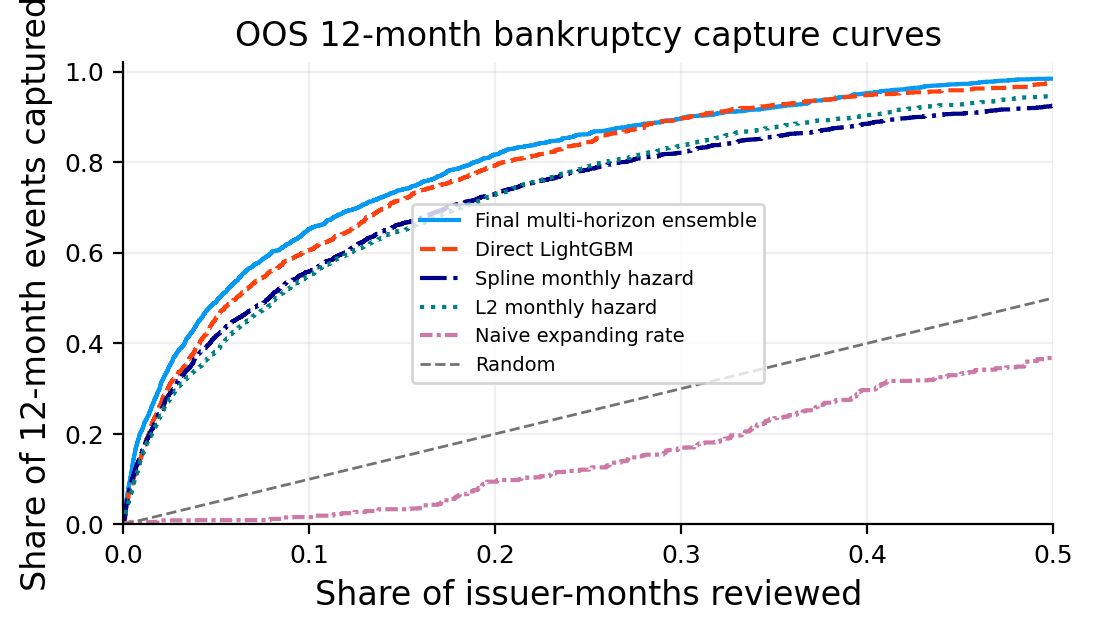

In [14]:
evaluation = forecast.merge(
    sample[["decision_date", "cik", "debt_assets", "ohlson_o", "zmijewski_x"]],
    on=["decision_date", "cik"], how="left")

naive_parts = []
for year in range(oos_start.year, last_month.year + 1):
    cutoff = pd.Timestamp(year, 1, 1)
    train = matured(sample, cutoff, 1, "event_1m")
    test = sample[sample["decision_date"].dt.year.eq(year)]
    h = train["event_1m"].mean()
    naive_parts.append(pd.DataFrame({
        "decision_date": test["decision_date"].to_numpy(),
        "cik": test["cik"].to_numpy(),
        "pd12_naive": np.repeat(1 - (1 - h) ** 12, len(test))
    }))
naive_predictions = pd.concat(naive_parts, ignore_index=True)
evaluation = evaluation.merge(
    naive_predictions, on=["decision_date", "cik"], how="left")

model_columns = {
    "Naive expanding rate": "pd12_naive",
    "L2 monthly hazard": "pd12_l2",
    "Spline monthly hazard": "pd12_gam",
    "LightGBM monthly hazard": "pd12_hazard",
    "Direct L2 logit": "pd12_direct_l2",
    "Direct spline logit": "pd12_spline",
    "Direct LightGBM": "pd12_tree",
    "Final multi-horizon ensemble": "pd12"
}
discrimination = pd.DataFrame({
    name: forecast_metrics(evaluation, column, "event_12m", 12)
    for name, column in model_columns.items()
}).T

end_12m = last_month - pd.offsets.MonthEnd(12)
benchmark_rows = []
for name, column in {
    "Debt / assets": "debt_assets",
    "Ohlson O-score, CPI-scaled size": "ohlson_o",
    "Zmijewski score": "zmijewski_x"
}.items():
    known = evaluation[
        evaluation["decision_date"].le(end_12m) & evaluation["observed_event_12m"]
    ][["event_12m", column]].dropna().sort_values(column, ascending=False)
    y = known["event_12m"].astype(int).to_numpy()
    n10 = max(1, int(0.10 * len(known)))
    benchmark_rows.append({
        "model": name, "rows": len(known), "positives": int(y.sum()),
        "ROC-AUC": roc_auc_score(y, known[column]),
        "PR-AUC": average_precision_score(y, known[column]),
        "Brier": np.nan, "log loss": np.nan,
        "top 10% capture": y[:n10].sum() / y.sum()
    })
discrimination = pd.concat([
    discrimination,
    pd.DataFrame(benchmark_rows).set_index("model")
])
display(discrimination.round(4))

capture_sample = evaluation[
    evaluation["decision_date"].le(end_12m) & evaluation["observed_event_12m"]]
capture_models = ["Final multi-horizon ensemble", "Direct LightGBM",
                  "Spline monthly hazard", "L2 monthly hazard", "Naive expanding rate"]
capture_styles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
for name, style in zip(capture_models, capture_styles):
    column = model_columns[name]
    ordered = capture_sample[["event_12m", column]].dropna().sort_values(
        column, ascending=False)
    x = np.arange(1, len(ordered) + 1) / len(ordered)
    y = ordered["event_12m"].cumsum() / ordered["event_12m"].sum()
    plt.plot(x, y, linestyle=style, label=name)
plt.plot([0, 1], [0, 1], color="0.45", linestyle="--", linewidth=1, label="Random")
plt.title("OOS 12-month bankruptcy capture curves")
plt.xlabel("Share of issuer-months reviewed")
plt.ylabel("Share of 12-month events captured")
plt.xlim(0, 0.5)
plt.ylim(0, 1.02)
plt.legend()
plt.show()

ROC-AUC  PR-AUC   Brier  log loss  top 10% capture
horizon model                                                                            
3       Frozen LightGBM hazard          0.9252  0.0631  0.0018    0.0100           0.7857
        Direct multi-horizon ensemble   0.9362  0.0568  0.0018    0.0099           0.7914
6       Frozen LightGBM hazard          0.9010  0.0811  0.0037    0.0193           0.7092
        Direct multi-horizon ensemble   0.9167  0.0712  0.0037    0.0187           0.7336
12      Frozen LightGBM hazard          0.8444  0.0898  0.0077    0.0392           0.5784
        Direct multi-horizon ensemble   0.8954  0.0996  0.0073    0.0350           0.6527
24      Frozen LightGBM hazard          0.7762  0.1008  0.0157    0.0788           0.4570
        Direct multi-horizon ensemble   0.8670  0.1335  0.0146    0.0647           0.5571

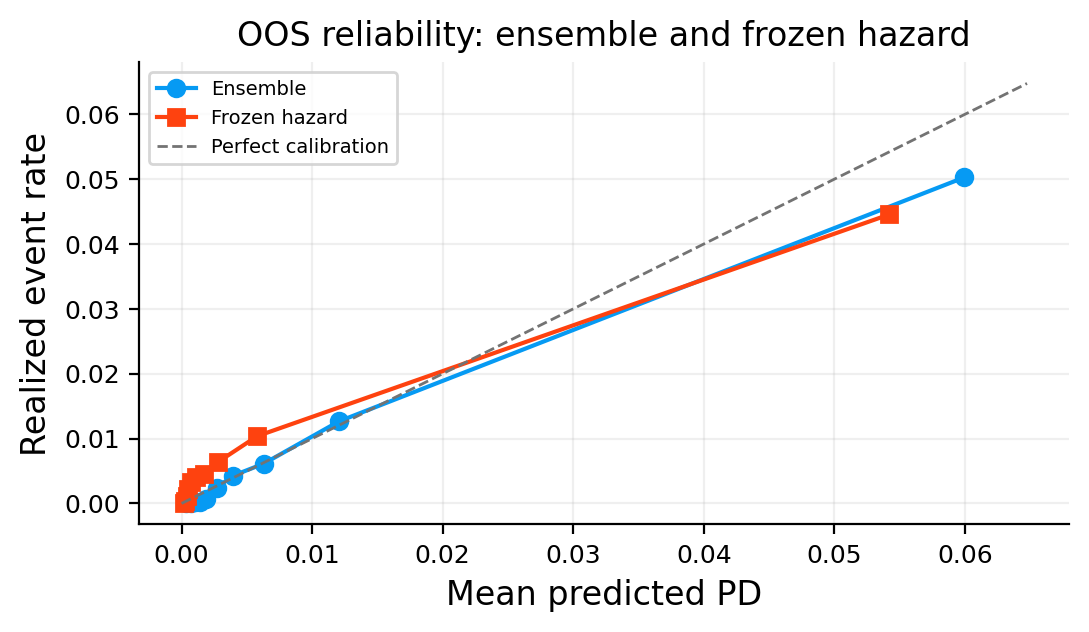

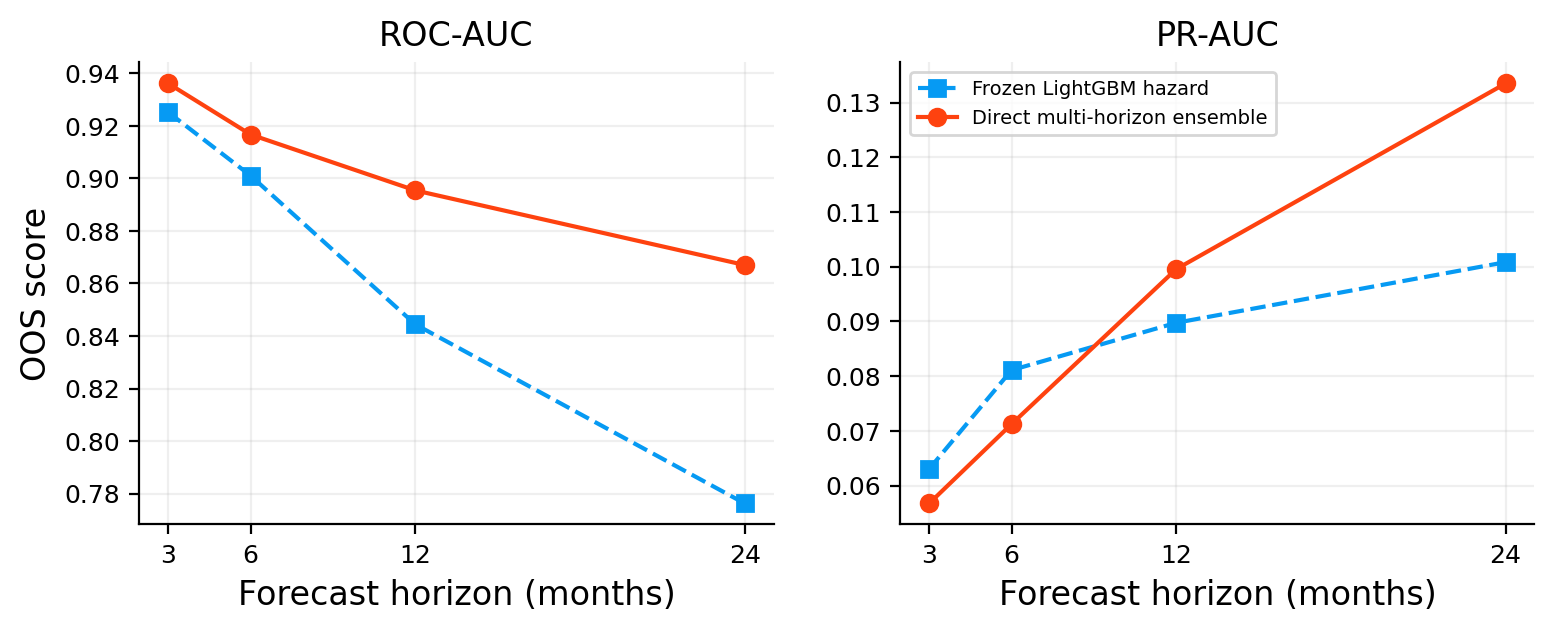

In [15]:
horizon_rows = []
for horizon in horizons:
    target = f"event_{horizon}m"
    for name, column in [
        ("Frozen LightGBM hazard", f"pd{horizon}_hazard"),
        ("Direct multi-horizon ensemble", f"pd{horizon}")
    ]:
        horizon_rows.append({
            "horizon": horizon, "model": name,
            **forecast_metrics(forecast, column, target, horizon)
        })
horizon_results = pd.DataFrame(horizon_rows)
display(horizon_results.set_index(["horizon", "model"])[
    ["ROC-AUC", "PR-AUC", "Brier", "log loss", "top 10% capture"]].round(4))

calibration = evaluation[
    evaluation["decision_date"].le(end_12m) & evaluation["observed_event_12m"]
][["event_12m", "pd12", "pd12_hazard"]].dropna()
reliability_curves = []
for probability, label, marker in [
    ("pd12", "Ensemble", "o"), ("pd12_hazard", "Frozen hazard", "s")
]:
    bins = pd.qcut(calibration[probability], 10, duplicates="drop")
    reliability = calibration.groupby(bins, observed=True).agg(
        predicted=(probability, "mean"), realized=("event_12m", "mean"))
    reliability_curves.append(reliability)
    plt.plot(reliability["predicted"], reliability["realized"], marker=marker, label=label)
limit = 1.08 * max(curve[["predicted", "realized"]].max().max()
                   for curve in reliability_curves)
plt.plot([0, limit], [0, limit], color="0.45", linestyle="--", linewidth=1,
         label="Perfect calibration")
plt.title("OOS reliability: ensemble and frozen hazard")
plt.xlabel("Mean predicted PD")
plt.ylabel("Realized event rate")
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for metric, ax in zip(["ROC-AUC", "PR-AUC"], axes):
    for name in ["Frozen LightGBM hazard", "Direct multi-horizon ensemble"]:
        curve = horizon_results[horizon_results["model"].eq(name)]
        style = "--" if name.startswith("Frozen") else "-"
        marker = "s" if name.startswith("Frozen") else "o"
        ax.plot(curve["horizon"], curve[metric], marker=marker,
                linestyle=style, label=name)
    ax.set_title(metric)
    ax.set_xlabel("Forecast horizon (months)")
    ax.set_xticks(horizons)
axes[0].set_ylabel("OOS score")
axes[1].legend()
plt.show()

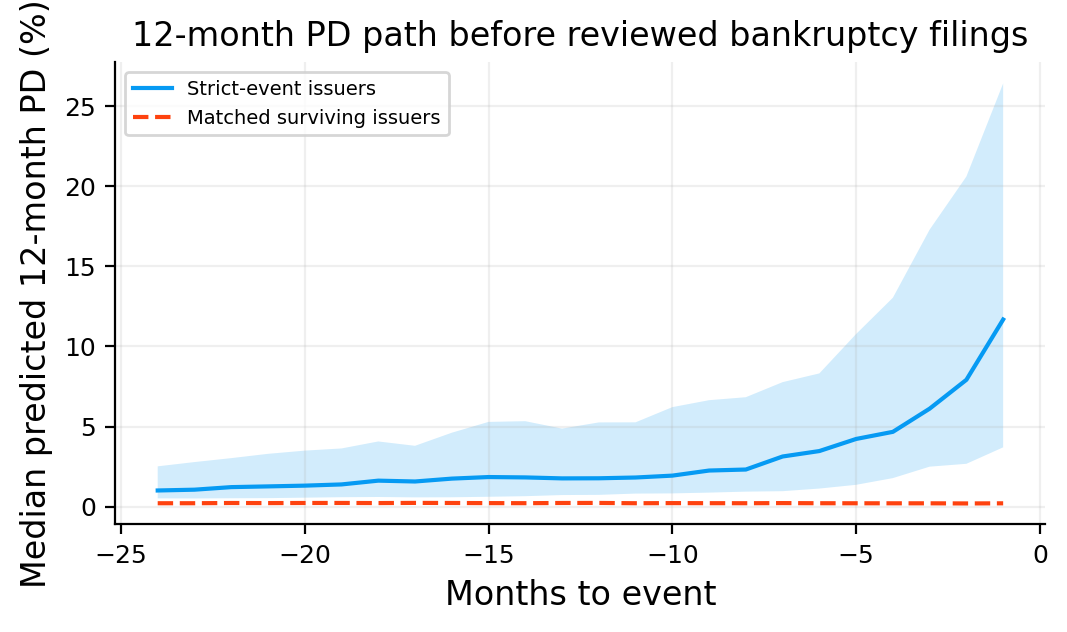

In [16]:
scored = sample.merge(
    forecast[["decision_date", "cik", "pd12", "h_lgb"]],
    on=["decision_date", "cik"], how="inner")
scored["size_decile"] = np.ceil(10 * scored.groupby("decision_date")["log_assets"].rank(
    pct=True)).clip(1, 10).astype("Int64")
event_month = scored["strict_date"].dt.to_period("M").astype("int64")
decision_month = scored["decision_date"].dt.to_period("M").astype("int64")
scored["tau"] = decision_month - event_month

event_paths = scored[scored["tau"].between(-24, -1)].copy()
survivor_summary = scored[
    ~scored["event_24m"] & scored["observed_event_24m"]].groupby(
    ["decision_date", "sic_division", "size_decile"], observed=True)["pd12"].median().rename(
    "matched_pd12").reset_index()
event_paths = event_paths.merge(
    survivor_summary, on=["decision_date", "sic_division", "size_decile"], how="left")
event_study = event_paths.groupby("tau").agg(
    failures=("cik", "nunique"), q25=("pd12", lambda x: x.quantile(0.25)),
    median=("pd12", "median"), q75=("pd12", lambda x: x.quantile(0.75)),
    matched=("matched_pd12", "median"))

plt.plot(event_study.index, 100 * event_study["median"], label="Strict-event issuers")
plt.fill_between(event_study.index, 100 * event_study["q25"],
                 100 * event_study["q75"], alpha=0.18)
plt.plot(event_study.index, 100 * event_study["matched"], linestyle="--",
         label="Matched surviving issuers")
plt.title("12-month PD path before reviewed bankruptcy filings")
plt.xlabel("Months to event")
plt.ylabel("Median predicted 12-month PD (%)")
plt.legend()
plt.show()
event_landmarks = 100 * event_study.loc[
    [-24, -18, -12, -6, -3, -1], ["median", "matched"]]

,mean absolute SHAP,highest-risk case SHAP,L2 coefficient
log_assets,0.5059,0.8192,0.3781
fcf_assets,0.2160,0.2694,0.0367
wc_assets,0.1949,0.2750,0.0607
current_ratio,0.1836,0.5350,-0.2198
liabilities_assets,0.1655,0.5132,-0.1051
operating_margin,0.1611,0.2322,0.0970
asset_growth,0.1497,0.2502,-0.0864
statement_age,0.1395,1.3912,0.3488
interest_coverage,0.1326,0.0908,0.0067
delisting_12m,0.1301,0.9672,0.2817


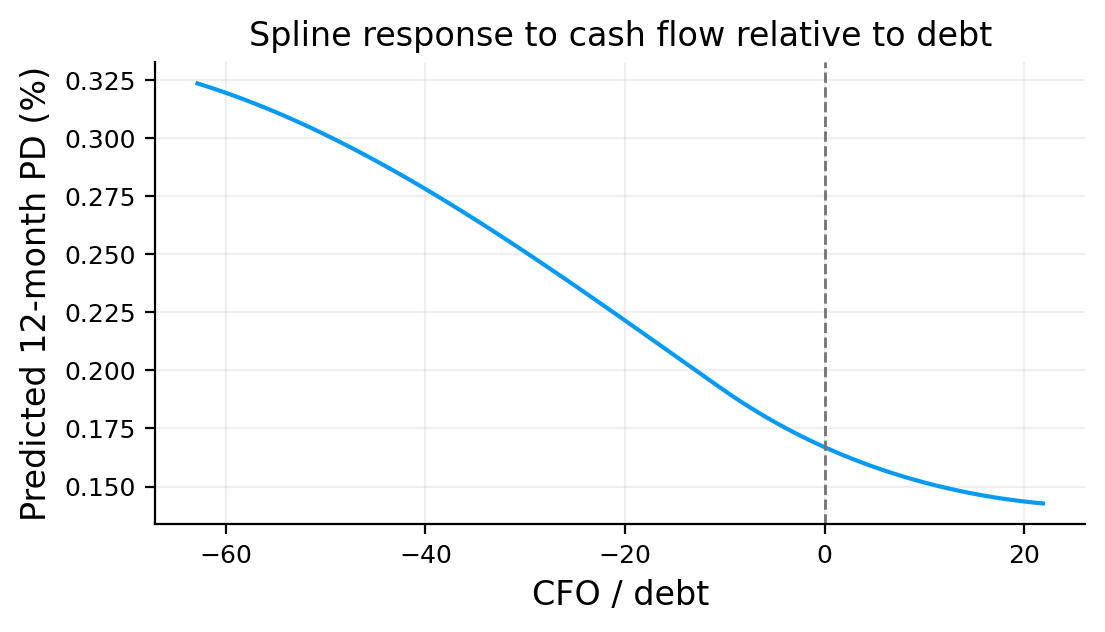

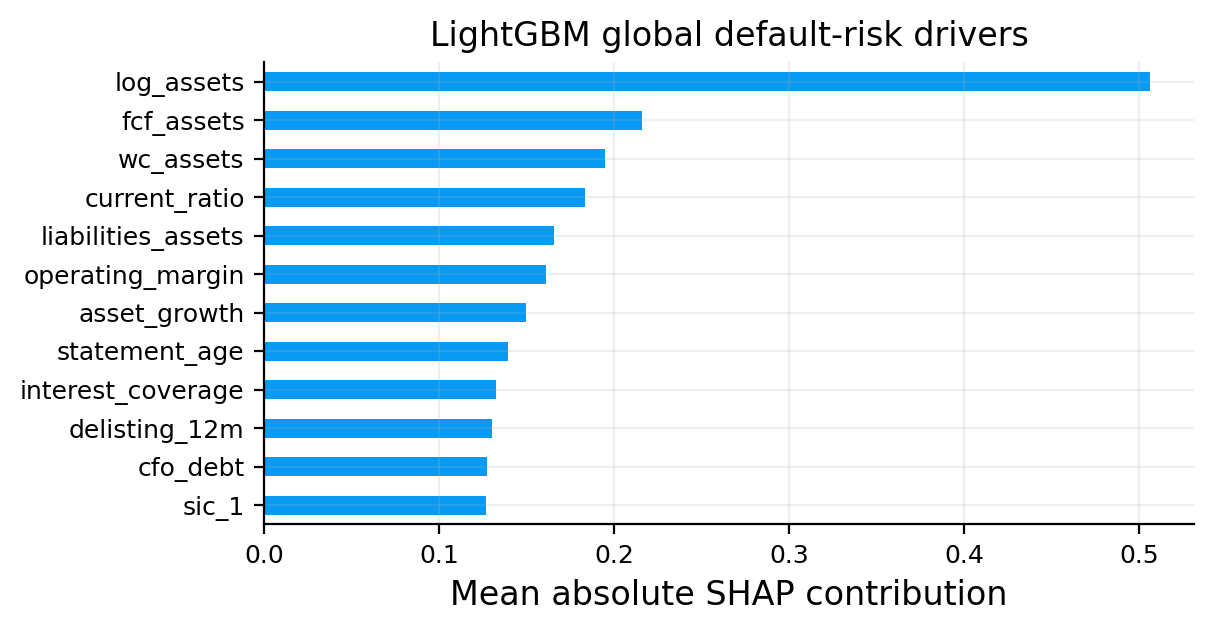

In [17]:
current_cutoff = last_month + pd.offsets.MonthEnd(1)
linear_train = matured(sample, current_cutoff, 1, "event_1m")
linear_fit = fit_linear(linear_train, linear_features, "event_1m")
linear_coefficients = pd.Series(
    linear_fit[0].coef_[0], index=linear_features, name="L2 coefficient")

direct_train = matured(sample, current_cutoff, 12, "event_12m")
direct_train = direct_train[direct_train["origin"].mod(12).eq(0)]
gam_fit = fit_gam(direct_train, "event_12m")
reference = direct_train[model_features].median().to_frame().T
cfo_grid = np.linspace(
    direct_train["cfo_debt"].quantile(0.02),
    direct_train["cfo_debt"].quantile(0.98), 120)
gam_grid = pd.concat([reference] * len(cfo_grid), ignore_index=True)
gam_grid["cfo_debt"] = cfo_grid
gam_effect = 100 * predict_gam(gam_fit, gam_grid)

choice = direct_choices.sort_values("year").iloc[-1]
X = direct_train[model_features].astype(float)
q = X.quantile([0.005, 0.995])
lo, hi = q.loc[0.005], q.loc[0.995]
tree = make_lgb(
    lgb_specs[int(choice["spec"])], int(direct_train["event_12m"].sum()),
    len(direct_train), int(choice["trees"]))
tree.fit(X.clip(lo, hi, axis=1), direct_train["event_12m"].astype(int),
         callbacks=[lgb.log_evaluation(0)])

explain = direct_train.sample(min(5000, len(direct_train)), random_state=22)
X_explain = explain[model_features].astype(float).clip(lo, hi, axis=1)
contributions = tree.booster_.predict(X_explain, pred_contrib=True)
global_shap = pd.Series(
    np.abs(contributions[:, :-1]).mean(axis=0), index=model_features,
    name="mean absolute SHAP")

latest_date = forecast["decision_date"].max()
case_key = forecast[forecast["decision_date"].eq(latest_date)].nlargest(1, "pd12")[
    ["decision_date", "cik"]]
case = sample.merge(case_key, on=["decision_date", "cik"], how="inner").iloc[[0]]
case_shap = pd.Series(
    tree.booster_.predict(
        case[model_features].astype(float).clip(lo, hi, axis=1),
        pred_contrib=True)[0, :-1],
    index=model_features, name="highest-risk case SHAP")

top_drivers = global_shap.nlargest(12).index
driver_table = pd.concat([
    global_shap.reindex(top_drivers),
    case_shap.reindex(top_drivers),
    linear_coefficients.reindex(top_drivers)
], axis=1)
display(driver_table.round(4))

plt.plot(cfo_grid, gam_effect)
plt.axvline(0, color="0.45", linestyle="--", linewidth=1)
plt.title("Spline response to cash flow relative to debt")
plt.xlabel("CFO / debt")
plt.ylabel("Predicted 12-month PD (%)")
plt.show()

global_shap.nlargest(12).sort_values().plot(kind="barh")
plt.title("LightGBM global default-risk drivers")
plt.xlabel("Mean absolute SHAP contribution")
plt.ylabel("")
plt.show()

In [18]:
state_path = cache / f"state_predictions_{model_version}.parquet"
if state_path.exists():
    state_predictions = pd.read_parquet(state_path)
else:
    state_parts = []
    for transition, data, target, spacing in [
        ("Healthy to distress", healthy, "broad_12m", 12),
        ("Distress to bankruptcy", distressed, "event_12m", 3)
    ]:
        l2 = expanding_linear(data, target, 12, spacing, model_features, kind="linear")
        tree_path = expanding_lgb_fixed(data, target, 12, spacing, direct_choices)
        path = l2.rename(columns={"p": "p_l2"}).merge(
            tree_path[["decision_date", "cik", "p"]].rename(columns={"p": "p_tree"}),
            on=["decision_date", "cik"], how="inner")
        path["p"] = path[["p_l2", "p_tree"]].mean(axis=1)
        path["transition"] = transition
        path["target"] = target
        state_parts.append(path)
    state_predictions = pd.concat(state_parts, ignore_index=True)
    state_predictions.to_parquet(state_path, index=False)

transition_rows = []
for transition, path in state_predictions.groupby("transition"):
    target = path["target"].iloc[0]
    transition_rows.append({
        "transition": transition, "model": "State ensemble",
        **forecast_metrics(path, "p", target, 12)
    })
transition_results = pd.DataFrame(transition_rows)

landmark_date = pd.Timestamp("2016-12-31")
landmark = sample[sample["decision_date"].eq(landmark_date)].copy()
event_after = landmark["strict_date"].gt(landmark_date) & landmark["strict_date"].le(
    landmark["last_observed"])
landmark = pd.concat([
    landmark[event_after],
    landmark[~event_after].sample(
        n=min(2000, int((~event_after).sum())), random_state=22)
]).sort_values("cik")
event_after = landmark["strict_date"].gt(landmark_date) & landmark["strict_date"].le(
    landmark["last_observed"])
cox_features = [
    "liabilities_assets", "debt_assets", "interest_coverage", "cfo_debt",
    "cash_assets", "current_ratio", "fcf_assets", "roa", "operating_margin",
    "sales_assets", "accruals", "distress_index"
]
X = landmark[cox_features].astype(float)
q = X.quantile([0.01, 0.99])
X = X.clip(q.loc[0.01], q.loc[0.99], axis=1).fillna(X.median())
X = (X - X.mean()) / X.std().replace(0.0, 1.0)
end = landmark["last_observed"].where(~event_after, landmark["strict_date"])
duration = (end - landmark_date).dt.days.div(30.4375).clip(lower=1.0)
cox = PHReg(duration, X, status=event_after.astype(int), ties="efron").fit(disp=0)

def harrell_c(duration, status, score):
    concordant = 0.0
    comparable = 0
    duration = np.asarray(duration)
    status = np.asarray(status, dtype=bool)
    score = np.asarray(score)
    for i in np.flatnonzero(status):
        at_risk = duration > duration[i]
        comparable += int(at_risk.sum())
        concordant += np.sum(score[i] > score[at_risk])
        concordant += 0.5 * np.sum(score[i] == score[at_risk])
    return concordant / comparable

cox_risk = X.to_numpy() @ cox.params
hazard_train = matured(sample, landmark_date, 1, "event_1m")
hazard_fit = fit_linear(hazard_train, linear_features, "event_1m")
landmark_hazard = predict_linear(hazard_fit, landmark, linear_features)
cox_results = pd.DataFrame({
    "Harrell C": [harrell_c(duration, event_after, cox_risk),
                  harrell_c(duration, event_after, landmark_hazard)]},
    index=["Landmark Cox PH", "Discrete L2 hazard"])
transition_table = transition_results.set_index(["transition", "model"])[
    ["ROC-AUC", "PR-AUC", "Brier", "log loss"]]
cox_table = cox_results.rename_axis("model").assign(
    transition="Strict survival", **{"ROC-AUC": np.nan, "PR-AUC": np.nan,
                                     "Brier": np.nan, "log loss": np.nan}
).reset_index().set_index(["transition", "model"])
transition_table = pd.concat([transition_table, cox_table])
display(transition_table.round(4))

ROC-AUC  PR-AUC   Brier  log loss  Harrell C
transition             model                                                           
Distress to bankruptcy State ensemble       0.7691  0.0740  0.0189    0.0876        NaN
Healthy to distress    State ensemble       0.7901  0.0924  0.0196    0.0888        NaN
Strict survival        Landmark Cox PH         NaN     NaN     NaN       NaN     0.6228
                       Discrete L2 hazard      NaN     NaN     NaN       NaN     0.6860

In [19]:
equity_history = read_equity_history(
    MARKET_PATH, start="2011-01-01",
    columns=["date", "ticker", "adj_close", "close", "volume", "is_sp500_member",
             "snapshot_date", "industry", "market_cap"])
equity = equity_history["market"]
equity["decision_date"] = equity["date"].dt.to_period("M").dt.to_timestamp("M")
equity_months = equity[equity["is_sp500_member"]].sort_values("date").groupby(
    ["decision_date", "ticker"], as_index=False).tail(1)

ticker_map = filings[
    ["ticker", "cik", "mapping_valid_from", "mapping_valid_to"]].dropna().drop_duplicates()
equity_months = equity_months.merge(ticker_map, on="ticker", how="inner")
valid_mapping = (
    equity_months["decision_date"].ge(equity_months["mapping_valid_from"])
    & equity_months["decision_date"].le(equity_months["mapping_valid_to"]))
equity_months = equity_months[valid_mapping].sort_values(
    ["decision_date", "cik", "market_cap"]).drop_duplicates(
    ["decision_date", "cik"], keep="last")

sp_overlap = credit.merge(
    equity_months[["decision_date", "cik", "ticker", "adj_close", "market_cap", "industry"]],
    on=["decision_date", "cik"], how="inner", suffixes=("_sec", "_market"))

In [20]:
returns = equity_history["returns"]
market_tickers = pd.Index(equity_months["ticker"].unique()).intersection(returns.columns)
returns = returns.loc[:, market_tickers]
sigma_E = returns.rolling(252, min_periods=126).std() * np.sqrt(252)
last_sessions = returns.index.to_series().groupby(returns.index.to_period("M")).max()
sigma_monthly = sigma_E.loc[last_sessions].rename_axis(index="date", columns="ticker").stack(
    future_stack=True).rename("sigma_E").reset_index()
sigma_monthly = sigma_monthly[sigma_monthly["sigma_E"].notna()]
sigma_monthly["decision_date"] = sigma_monthly["date"].dt.to_period("M").dt.to_timestamp("M")

merton_inputs = sp_overlap.merge(
    sigma_monthly[["decision_date", "ticker", "sigma_E"]],
    left_on=["decision_date", "ticker_market"], right_on=["decision_date", "ticker"],
    how="left").rename(columns={"market_cap": "E"})

distress_overlap = merton_inputs[
    merton_inputs["strict_date"].notna()
    & merton_inputs["decision_date"].ge(merton_inputs["strict_date"] - pd.DateOffset(months=12))
    & merton_inputs["decision_date"].lt(merton_inputs["strict_date"])]
market_audit = pd.DataFrame({"value": {
    "daily market rows": len(equity),
    "PIT member-months": len(equity_months),
    "SEC overlap issuer-months": len(sp_overlap),
    "SEC overlap issuers": sp_overlap["cik"].nunique(),
    "equity volatility coverage": merton_inputs["sigma_E"].notna().mean(),
    "strict-event issuers with prior market data": distress_overlap["cik"].nunique()
}})
display(market_audit)

,value
daily market rows,2.430648e+06
PIT member-months,6.162700e+04
SEC overlap issuer-months,5.808400e+04
SEC overlap issuers,4.750000e+02
equity volatility coverage,9.982956e-01
strict-event issuers with prior market data,1.000000e+00


In [21]:
tnc_1y = con.execute(f"""
    SELECT date, yield_percent / 100.0 AS r
    FROM read_parquet('{CURVE_PATH.as_posix()}')
    WHERE curve_family = 'TNC' AND rate_type = 'spot'
      AND observation_type = 'end_of_month' AND maturity_years = 1.0
""").fetchdf()
tnc_1y["decision_date"] = pd.to_datetime(tnc_1y["date"]).dt.to_period("M").dt.to_timestamp("M")
merton_inputs = merton_inputs.merge(tnc_1y[["decision_date", "r"]], on="decision_date", how="left")

merton_inputs["D"] = merton_inputs["total_liabilities"]
merton_inputs = merton_inputs[
    merton_inputs["E"].gt(0) & merton_inputs["sigma_E"].gt(0)
    & merton_inputs["D"].gt(0) & merton_inputs["r"].notna()].copy()

default_point_audit = merton_inputs[["D", "E"]].describe(
    percentiles=[0.1, 0.5, 0.9]).T[["count", "mean", "10%", "50%", "90%"]]
default_point_audit["median / equity"] = merton_inputs["D"].div(merton_inputs["E"]).median()

In [22]:
def merton_solution(E, sigma_E, D, r, T=1.0, tol=1e-8, max_iter=100):
    E = np.asarray(E, dtype=float)
    sigma_E = np.asarray(sigma_E, dtype=float)
    D = np.asarray(D, dtype=float)
    r = np.asarray(r, dtype=float)
    valid = np.isfinite(E + sigma_E + D + r) & (E > 0) & (sigma_E > 0) & (D > 0)
    result = {name: np.full(len(E), np.nan)
              for name in ["V", "sigma_V", "d1", "d2", "pd_merton", "residual"]}
    result["converged"] = np.zeros(len(E), dtype=bool)
    result["iterations"] = np.zeros(len(E), dtype=int)
    if not valid.any():
        return pd.DataFrame(result)
    Ev, sigma_Ev, Dv, rv = E[valid], sigma_E[valid], D[valid], r[valid]
    V = Ev + Dv * np.exp(-rv * T)
    sigma_V = sigma_Ev * Ev / V
    converged = np.zeros(len(Ev), dtype=bool)
    iterations = np.zeros(len(Ev), dtype=int)
    for iteration in range(1, max_iter + 1):
        d1 = (np.log(V / Dv) + (rv + 0.5 * sigma_V ** 2) * T) / (sigma_V * np.sqrt(T))
        d2 = d1 - sigma_V * np.sqrt(T)
        Nd1 = np.clip(norm.cdf(d1), 1e-10, 1.0)
        V_new = (Ev + Dv * np.exp(-rv * T) * norm.cdf(d2)) / Nd1
        sigma_new = sigma_Ev * Ev / (Nd1 * V_new)
        change = np.maximum(np.abs(V_new / V - 1.0), np.abs(sigma_new / sigma_V - 1.0))
        newly_converged = ~converged & (change < tol)
        iterations[newly_converged] = iteration
        converged |= newly_converged
        V = 0.5 * V + 0.5 * V_new
        sigma_V = 0.5 * sigma_V + 0.5 * sigma_new
        if converged.all():
            break
    iterations[~converged] = max_iter
    d1 = (np.log(V / Dv) + (rv + 0.5 * sigma_V ** 2) * T) / (sigma_V * np.sqrt(T))
    d2 = d1 - sigma_V * np.sqrt(T)
    E_hat = V * norm.cdf(d1) - Dv * np.exp(-rv * T) * norm.cdf(d2)
    sigma_E_hat = norm.cdf(d1) * V * sigma_V / Ev
    residual = np.maximum(np.abs(E_hat / Ev - 1.0), np.abs(sigma_E_hat / sigma_Ev - 1.0))
    result["V"][valid] = V
    result["sigma_V"][valid] = sigma_V
    result["d1"][valid] = d1
    result["d2"][valid] = d2
    result["pd_merton"][valid] = norm.cdf(-d2)
    result["converged"][valid] = converged
    result["iterations"][valid] = iterations
    result["residual"][valid] = residual
    return pd.DataFrame(result)

solution = merton_solution(
    merton_inputs["E"], merton_inputs["sigma_E"], merton_inputs["D"], merton_inputs["r"])
merton = pd.concat([
    merton_inputs.reset_index(drop=True),
    solution
], axis=1)
merton["dd_q"] = merton["d2"]
assert merton["converged"].mean() > 0.95

,rows,positives,ROC-AUC,PR-AUC,Brier,log loss,strict OOS issuer-months,strict OOS issuers
Accounting ensemble,11609.0,70.0,0.6766,0.0093,0.0061,0.0401,0,0
Calibrated Merton,11609.0,70.0,0.7460,0.0167,0.0060,0.0362,0,0


,ticker,entity_name,sec_industry,pd12,pd_merton,rank_gap
13999,PYPL,"PayPal Holdings, Inc.","Services-Business Services, NEC",0.0001,0.0117,-0.8955
13746,FSLR,"FIRST SOLAR, INC.",Semiconductors & Related Devices,0.0001,0.0107,-0.8000
13650,ON,ON SEMICONDUCTOR CORP,Semiconductors & Related Devices,0.0003,0.0111,-0.7364
13354,INCY,INCYTE CORP,Services-Commercial Physical & Biological Rese...,0.0020,0.0065,0.7273
12875,CL,COLGATE PALMOLIVE CO,"Perfumes, Cosmetics & Other Toilet Preparations",0.0015,0.0056,0.7045
13471,TTWO,TAKE TWO INTERACTIVE SOFTWARE INC,Services-Prepackaged Software,0.0025,0.0069,0.7045
13782,PANW,Palo Alto Networks Inc,"Computer Peripheral Equipment, NEC",0.0031,0.0073,0.6773
14096,CEG,Constellation Energy Corp,Electric Services,0.0004,0.0118,-0.6773
13402,NVR,NVR INC,Operative Builders,0.0015,0.0060,0.6727
13283,JCI,Johnson Controls International plc,Air-Cond & Warm Air Heatg Equip & Comm & Indl ...,0.0013,0.0057,0.6682


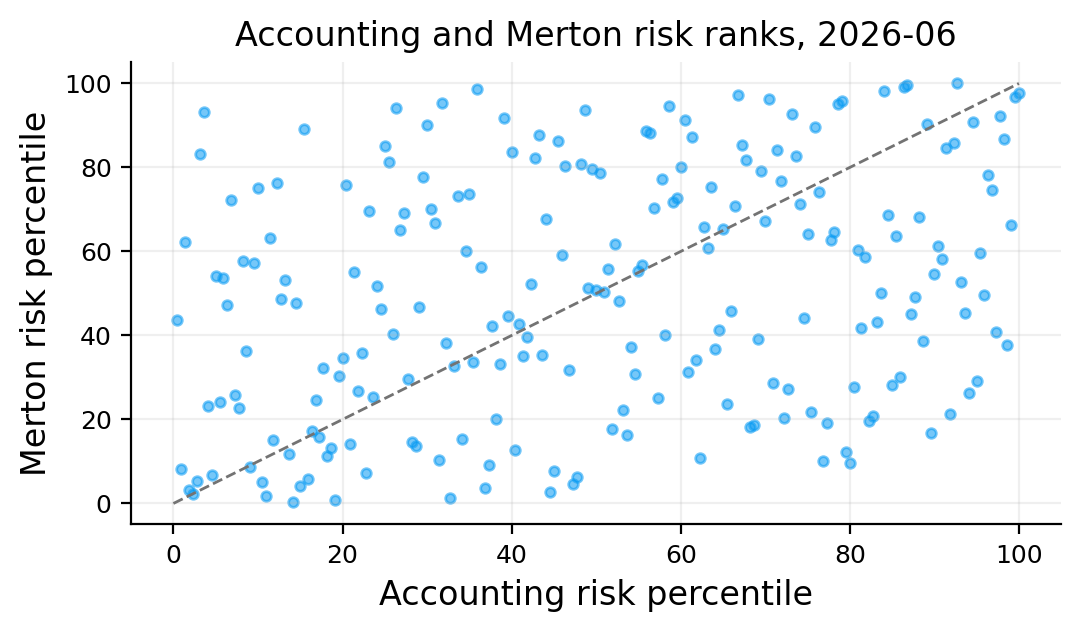

In [23]:
merton["origin"] = (
    (merton["decision_date"].dt.year - sample_start.year) * 12
    + merton["decision_date"].dt.month - sample_start.month)
merton["merton_score"] = -merton["d2"]
merton["merton_score_sq"] = merton["merton_score"] ** 2
merton_parts = []
for year in range(oos_start.year, last_month.year + 1):
    cutoff = pd.Timestamp(year, 1, 1)
    healthy_history = merton[
        merton["broad_date"].isna() | merton["decision_date"].lt(merton["broad_date"])]
    train = matured(healthy_history, cutoff, 12, "broad_12m")
    train = train[train["origin"].mod(12).eq(0)].dropna(subset=["merton_score"])
    test = healthy_history[healthy_history["decision_date"].dt.year.eq(year)].dropna(
        subset=["merton_score"])
    if test.empty or train["broad_12m"].sum() < 10:
        continue
    fit = fit_linear(
        train, ["merton_score", "merton_score_sq"], "broad_12m", C=0.25)
    merton_parts.append(pd.DataFrame({
        "decision_date": test["decision_date"].to_numpy(),
        "cik": test["cik"].to_numpy(),
        "entity_name": test["entity_name"].to_numpy(),
        "ticker": test["ticker_market"].to_numpy(),
        "sec_industry": test["sec_industry"].to_numpy(),
        "broad_12m": test["broad_12m"].to_numpy(),
        "observed_broad_12m": test["observed_broad_12m"].to_numpy(),
        "event_12m": test["event_12m"].to_numpy(),
        "pd_merton": predict_linear(
            fit, test, ["merton_score", "merton_score_sq"])
    }))
merton_predictions = pd.concat(merton_parts, ignore_index=True)
merton_common = merton_predictions.merge(
    forecast[["decision_date", "cik", "pd12"]],
    on=["decision_date", "cik"], how="inner")
merton_oos = merton_common[
    merton_common["decision_date"].le(end_12m)
    & merton_common["observed_broad_12m"]].copy()

def structural_metrics(data, score):
    p = data[score].clip(1e-8, 1 - 1e-8)
    y = data["broad_12m"].astype(int)
    return {
        "rows": len(data), "positives": int(y.sum()),
        "ROC-AUC": roc_auc_score(y, p),
        "PR-AUC": average_precision_score(y, p),
        "Brier": brier_score_loss(y, p), "log loss": log_loss(y, p)
    }

merton_comparison = pd.DataFrame({
    "Accounting ensemble": structural_metrics(merton_oos, "pd12"),
    "Calibrated Merton": structural_metrics(merton_oos, "pd_merton")
}).T
merton_comparison["strict OOS issuer-months"] = int(merton_oos["event_12m"].sum())
merton_comparison["strict OOS issuers"] = merton_oos.loc[
    merton_oos["event_12m"], "cik"].nunique()
display(merton_comparison.round(4))

latest_common_date = merton_common["decision_date"].max()
latest_common = merton_common[merton_common["decision_date"].eq(latest_common_date)].copy()
latest_common["accounting_rank"] = latest_common["pd12"].rank(pct=True)
latest_common["merton_rank"] = latest_common["pd_merton"].rank(pct=True)
latest_common["rank_gap"] = latest_common["accounting_rank"] - latest_common["merton_rank"]
disagreements = latest_common.reindex(latest_common["rank_gap"].abs().nlargest(12).index)[
    ["ticker", "entity_name", "sec_industry", "pd12", "pd_merton", "rank_gap"]]
display(disagreements.round(4))

plt.scatter(100 * latest_common["accounting_rank"], 100 * latest_common["merton_rank"],
            s=12, alpha=0.55)
plt.plot([0, 100], [0, 100], color="0.45", linestyle="--", linewidth=1)
plt.title(f"Accounting and Merton risk ranks, {latest_common_date:%Y-%m}")
plt.xlabel("Accounting risk percentile")
plt.ylabel("Merton risk percentile")
plt.show()

In [24]:
curves = pd.read_parquet(CURVE_PATH)
curves["date"] = pd.to_datetime(curves["date"]).dt.to_period("M").dt.to_timestamp("M")
fed = pd.read_parquet(FED_PATH)
fed["decision_date"] = pd.to_datetime(fed["date"]).dt.to_period("M").dt.to_timestamp("M")

curve_schema = curves.groupby(["curve_family", "rate_type", "observation_type"]).agg(
    rows=("yield_percent", "size"), first_date=("date", "min"), last_date=("date", "max"),
    min_maturity=("maturity_years", "min"), max_maturity=("maturity_years", "max"))
assert {"HQM", "TNC"}.issubset(curves["curve_family"].unique())
assert {"spot", "par"}.issubset(curves["rate_type"].unique())
assert {"gz_spread", "ebp", "est_prob"}.issubset(fed.columns)
assert not curves.duplicated(
    ["curve_family", "rate_type", "observation_type", "date", "maturity_years"]).any()

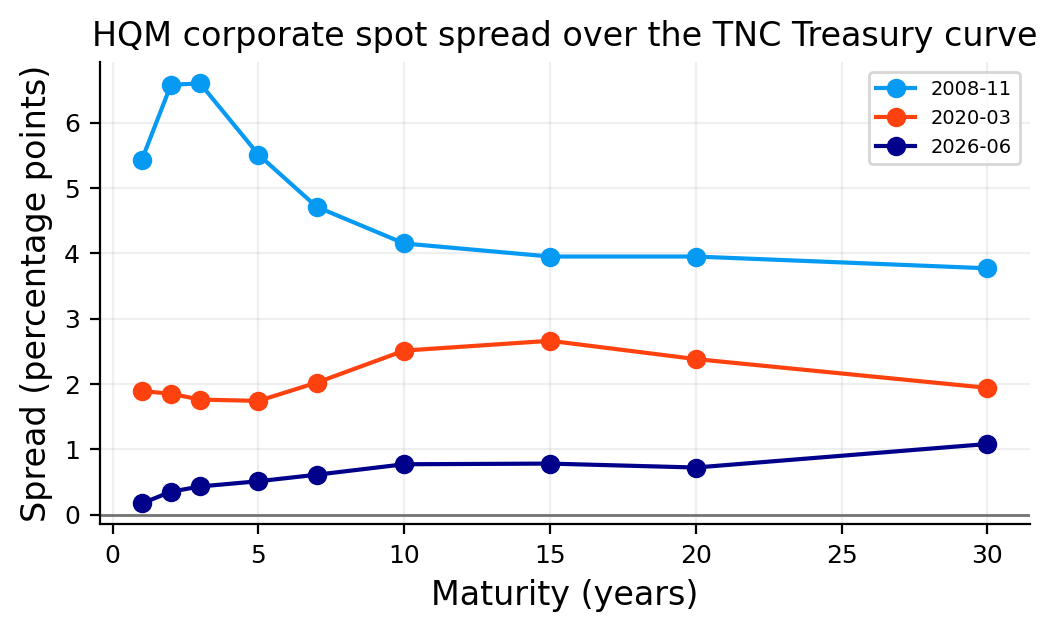

,spread_2y,spread_5y,spread_10y,spread_30y,slope_10y_2y
date,,,,,
2008-11-30,6.58,5.51,4.15,3.77,-2.43
2020-03-31,1.85,1.74,2.51,1.94,0.66
2026-06-30,0.35,0.51,0.77,1.08,0.42


In [25]:
maturities = [1, 2, 3, 5, 7, 10, 15, 20, 30]
spot = curves[
    curves["rate_type"].eq("spot") & curves["observation_type"].eq("end_of_month")
    & curves["maturity_years"].isin(maturities)]
hqm = spot[spot["curve_family"].eq("HQM")].pivot(
    index="date", columns="maturity_years", values="yield_percent")
tnc = spot[spot["curve_family"].eq("TNC")].pivot(
    index="date", columns="maturity_years", values="yield_percent")
hqm_spread = hqm.subtract(tnc).dropna(how="all")
hqm_spread.columns.name = None
spread_features = pd.DataFrame({
    "spread_2y": hqm_spread[2], "spread_5y": hqm_spread[5],
    "spread_10y": hqm_spread[10], "spread_30y": hqm_spread[30],
    "slope_10y_2y": hqm_spread[10] - hqm_spread[2]
})

requested_dates = pd.DatetimeIndex(["2008-11-30", "2020-03-31", hqm_spread.index.max()])
stress_dates = hqm_spread.index[hqm_spread.index.get_indexer(requested_dates, method="nearest")]
for date in stress_dates.unique():
    plt.plot(hqm_spread.columns, hqm_spread.loc[date], marker="o", label=f"{date:%Y-%m}")
plt.axhline(0, color="0.45", linewidth=1)
plt.title("HQM corporate spot spread over the TNC Treasury curve")
plt.xlabel("Maturity (years)")
plt.ylabel("Spread (percentage points)")
plt.legend()
plt.show()
display(spread_features.loc[stress_dates.unique()].round(3))

In [26]:
risk = forecast.merge(
    sample[["decision_date", "cik", "debt", "entity_name", "sec_industry"]].drop_duplicates(
        ["decision_date", "cik"]),
    on=["decision_date", "cik"], how="left")
members = equity_months[["decision_date", "cik", "ticker", "market_cap"]].rename(
    columns={"market_cap": "E"}).copy()
members["is_member"] = True
risk = risk.merge(members, on=["decision_date", "cik"], how="left")
risk["is_member"] = risk["is_member"].fillna(False)
risk = risk[risk["debt"].gt(0)].copy()
risk["lambda_p"] = -np.log1p(-risk["pd12"].clip(upper=1 - 1e-10))
risk["l2_loss_pp"] = 100 * LGD * risk["pd12_l2"]

def debt_weighted(data, value):
    known = data[data[value].notna() & data["debt"].gt(0)].copy()
    known["weighted"] = known[value] * known["debt"]
    result = known.groupby("decision_date").agg(
        weighted=("weighted", "sum"), debt=("debt", "sum"), issuers=("cik", "nunique"))
    result[value] = result["weighted"] / result["debt"]
    return result[[value, "issuers"]]

physical_loss = debt_weighted(risk, "l2_loss_pp").rename(
    columns={"l2_loss_pp": "l2_loss_pp", "issuers": "broad_issuers"})
physical_loss = physical_loss.join(
    debt_weighted(risk[risk["is_member"]], "l2_loss_pp").rename(
        columns={"l2_loss_pp": "member_l2_loss_pp", "issuers": "member_issuers"}),
    how="outer")

,gz_default_component
l2_loss_pp,0.638
member_l2_loss_pp,0.550


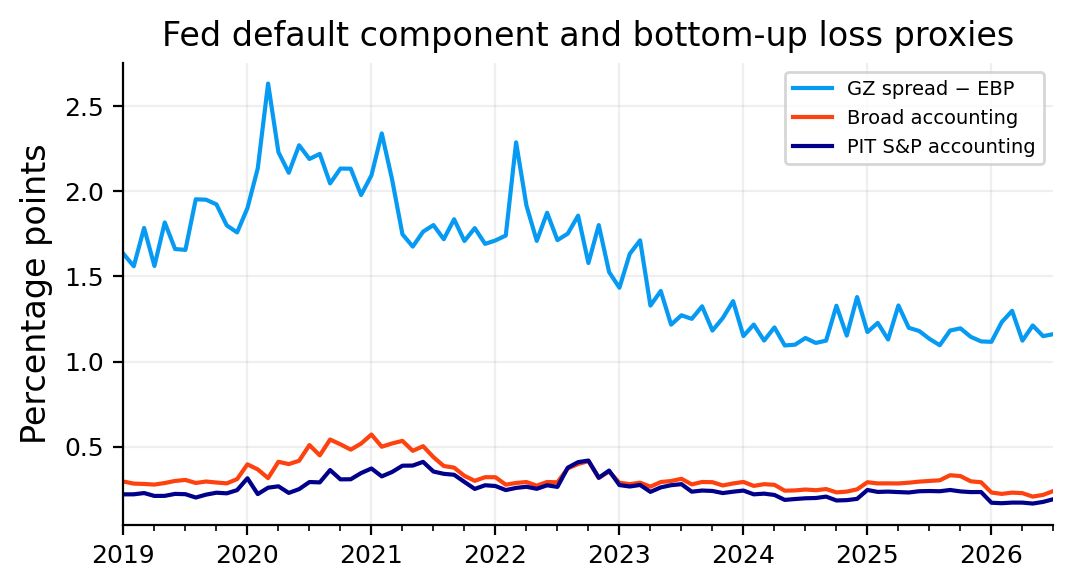

In [27]:
comparison = fed.set_index("decision_date")[["gz_spread", "ebp", "est_prob"]].join(
    physical_loss, how="inner")
comparison["gz_default_component"] = comparison["gz_spread"] - comparison["ebp"]

proxy_columns = ["l2_loss_pp", "member_l2_loss_pp"]
proxy_correlations = comparison[["gz_default_component", *proxy_columns]].corr(
    method="spearman").loc[proxy_columns, ["gz_default_component"]]
display(proxy_correlations.round(3))

comparison[["gz_default_component", "l2_loss_pp", "member_l2_loss_pp"]].plot()
plt.title("Fed default component and bottom-up loss proxies")
plt.ylabel("Percentage points")
plt.xlabel("")
plt.legend(["GZ spread − EBP", "Broad accounting", "PIT S&P accounting"])
plt.show()

In [28]:
def expanding_mapping(data, features, target, min_train=12):
    prediction = pd.Series(np.nan, index=data.index, dtype=float)
    for i in range(min_train, len(data)):
        train = data.iloc[:i].dropna(subset=[*features, target])
        test = data.iloc[[i]]
        if len(train) < min_train or test[features].isna().any(axis=None):
            continue
        mu = train[features].mean()
        sigma = train[features].std().replace(0.0, 1.0)
        model = Ridge(alpha=1.0)
        model.fit((train[features] - mu) / sigma, train[target])
        prediction.iloc[i] = model.predict((test[features] - mu) / sigma)[0]
    return prediction.clip(lower=0.0)

mapping_data = comparison.reset_index().sort_values("decision_date").reset_index(drop=True)
mapping_data["mapped_l2"] = expanding_mapping(
    mapping_data, ["l2_loss_pp"], "gz_default_component")

,months,correlation,regression intercept,regression slope,RMSE,mean error
Accounting L2,79.0,0.792,0.069,0.631,0.316,-0.212


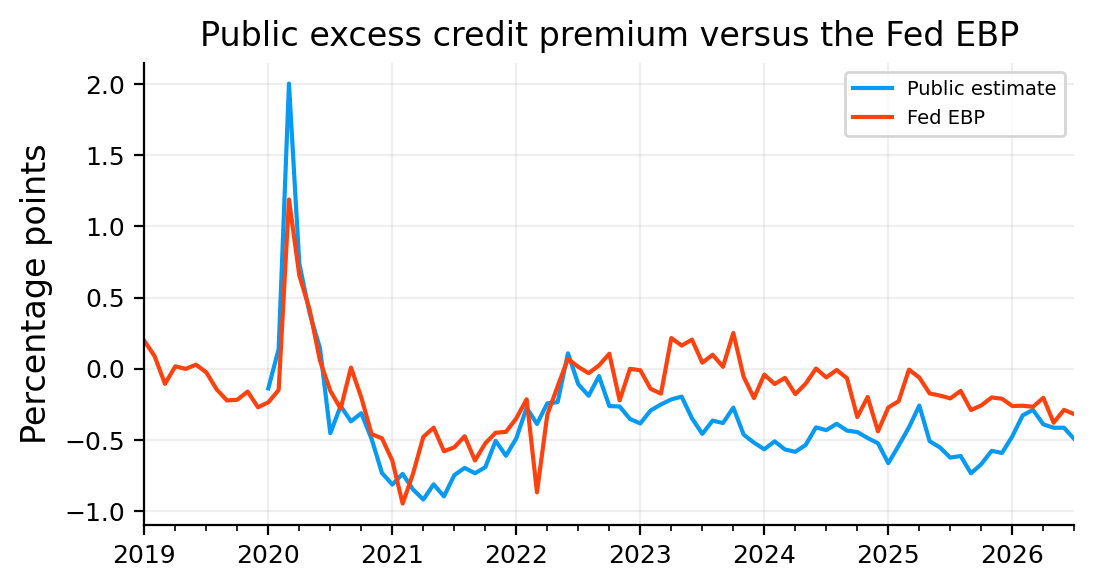

In [29]:
mapping_data["premium_l2"] = mapping_data["gz_spread"] - mapping_data["mapped_l2"]
mapping_data["public_excess_credit_premium"] = mapping_data["premium_l2"]

def premium_metrics(data, column):
    known = data[[column, "ebp"]].dropna()
    model = LinearRegression().fit(known[[column]], known["ebp"])
    error = known[column] - known["ebp"]
    return {
        "months": len(known), "correlation": known.corr().iloc[0, 1],
        "regression intercept": model.intercept_, "regression slope": model.coef_[0],
        "RMSE": np.sqrt(np.mean(error ** 2)), "mean error": error.mean()
    }

premium_validation = pd.DataFrame({
    "Accounting L2": premium_metrics(mapping_data, "premium_l2")
}).T
display(premium_validation.round(3))

mapping_data.set_index("decision_date")[
    ["premium_l2", "ebp"]].plot()
plt.title("Public excess credit premium versus the Fed EBP")
plt.ylabel("Percentage points")
plt.xlabel("")
plt.legend(["Public estimate", "Fed EBP"])
plt.show()

In [30]:
cmdi = pd.read_parquet(CMDI_PATH)
cmdi["decision_date"] = pd.to_datetime(cmdi["date"]).dt.to_period("M").dt.to_timestamp("M")
cmdi_monthly = cmdi.sort_values("date").groupby("decision_date", as_index=False).tail(1)
premium_cmdi = mapping_data.merge(
    cmdi_monthly[["decision_date", "market_cmdi", "ig_cmdi", "hy_cmdi"]],
    on="decision_date", how="inner").sort_values("decision_date")
cmdi_relationship = pd.DataFrame({
    "level correlation": premium_cmdi[
        ["public_excess_credit_premium", "ebp", "market_cmdi", "ig_cmdi", "hy_cmdi"]].corr()[
        ["public_excess_credit_premium", "ebp"]].loc[["market_cmdi", "ig_cmdi", "hy_cmdi"]].stack(),
    "change correlation": premium_cmdi[
        ["public_excess_credit_premium", "ebp", "market_cmdi", "ig_cmdi", "hy_cmdi"]].diff().corr()[
        ["public_excess_credit_premium", "ebp"]].loc[["market_cmdi", "ig_cmdi", "hy_cmdi"]].stack()
})

,premium_change,cmdi_change
ig_advance_decline,-0.094,-0.009
hy_advance_decline,-0.375,-0.016
ig_high_low,0.011,-0.273
hy_high_low,-0.266,-0.359
ig_customer_imbalance,-0.002,0.040
hy_customer_imbalance,-0.487,-0.444


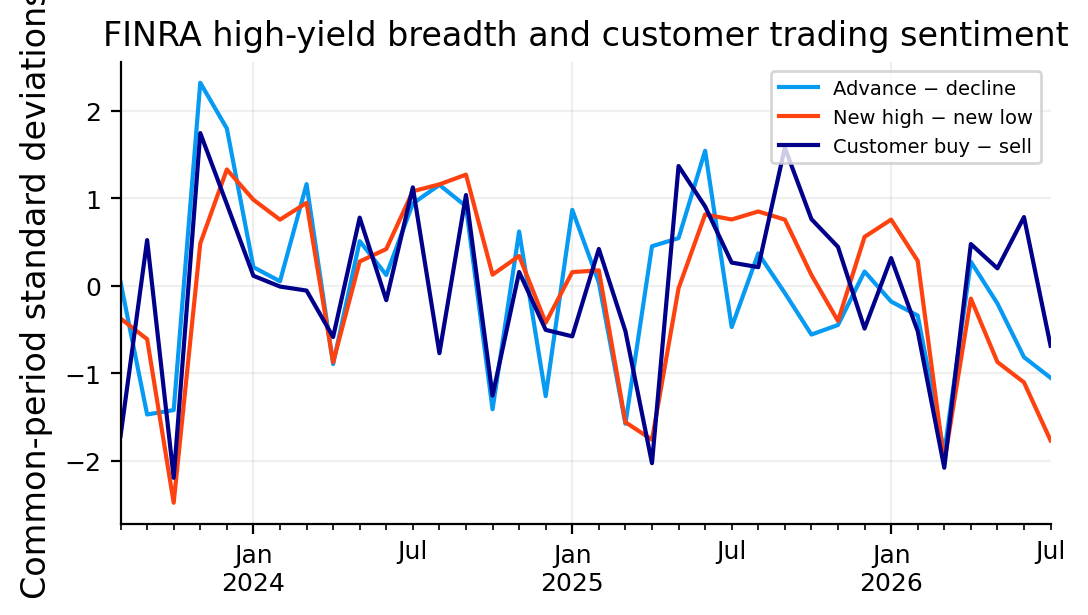

In [31]:
finra = pd.read_parquet(FINRA_PATH)
finra["date"] = pd.to_datetime(finra["date"])
corporate = finra[finra["market"].eq("corporate")].copy()

breadth = corporate[corporate["dataset"].eq("breadth")].pivot_table(
    index=["date", "security_category"], columns="source_field", values="value",
    aggfunc="last").reset_index()
breadth = breadth[breadth["security_category"].isin(["investment grade", "high yield"])]
breadth["grade"] = breadth["security_category"].map(
    {"investment grade": "IG", "high yield": "HY"})
breadth["advance_decline"] = safe_ratio(
    breadth["advances"] - breadth["declines"], breadth["advances"] + breadth["declines"],
    positive_denominator=True)
breadth["high_low"] = safe_ratio(
    breadth["fifty_two_week_high"] - breadth["fifty_two_week_low"],
    breadth["fifty_two_week_high"] + breadth["fifty_two_week_low"],
    positive_denominator=True)

sentiment = corporate[
    corporate["dataset"].eq("sentiment")
    & corporate["security_category"].isin(["investment grade", "high yield"])
    & corporate["trade_side"].isin(["customer buy", "customer sell"])
    & corporate["source_field"].eq("total_volume")].pivot_table(
    index=["date", "security_category"], columns="trade_side", values="value",
    aggfunc="last").reset_index()
sentiment["grade"] = sentiment["security_category"].map(
    {"investment grade": "IG", "high yield": "HY"})
sentiment["customer_imbalance"] = safe_ratio(
    sentiment["customer buy"] - sentiment["customer sell"],
    sentiment["customer buy"] + sentiment["customer sell"], positive_denominator=True)

daily_finra = breadth[["date", "grade", "advance_decline", "high_low", "total_volume",
                       "total_trades"]].merge(
    sentiment[["date", "grade", "customer_imbalance"]], on=["date", "grade"], how="outer")
daily_finra["decision_date"] = daily_finra["date"].dt.to_period("M").dt.to_timestamp("M")
monthly_finra = daily_finra.groupby(["decision_date", "grade"])[
    ["advance_decline", "high_low", "customer_imbalance", "total_volume", "total_trades"]
].mean().unstack()
monthly_finra.columns = [f"{grade.lower()}_{name}" for name, grade in monthly_finra.columns]
monthly_finra = monthly_finra.reset_index()

finra_validation = premium_cmdi.merge(monthly_finra, on="decision_date", how="inner")
finra_validation["premium_change"] = finra_validation["public_excess_credit_premium"].diff()
finra_validation["cmdi_change"] = finra_validation["market_cmdi"].diff()
finra_columns = ["ig_advance_decline", "hy_advance_decline", "ig_high_low", "hy_high_low",
                 "ig_customer_imbalance", "hy_customer_imbalance"]
finra_relationship = finra_validation[["premium_change", "cmdi_change", *finra_columns]].corr().loc[
    finra_columns, ["premium_change", "cmdi_change"]]
display(finra_relationship.round(3))

signals = finra_validation.set_index("decision_date")[
    ["hy_advance_decline", "hy_high_low", "hy_customer_imbalance"]]
signals = (signals - signals.mean()) / signals.std()
signals.plot()
plt.title("FINRA high-yield breadth and customer trading sentiment")
plt.ylabel("Common-period standard deviations")
plt.xlabel("")
plt.legend(["Advance − decline", "New high − new low", "Customer buy − sell"])
plt.show()

In [32]:
def survival_probability(t, knots, lambdas):
    t = np.atleast_1d(np.asarray(t, dtype=float))
    knots = np.asarray(knots, dtype=float)
    lambdas = np.asarray(lambdas, dtype=float)
    H = np.zeros_like(t)
    left = 0.0
    for right, lambda_j in zip(knots, lambdas):
        H += lambda_j * np.clip(np.minimum(t, right) - left, 0.0, right - left)
        left = right
    H += lambdas[-1] * np.maximum(t - knots[-1], 0.0)
    return np.exp(-H)

def cds_legs(lambdas, knots, zero_rates, T, R=R, frequency=4):
    dt = 1.0 / frequency
    t = np.arange(dt, T + 0.5 * dt, dt)
    r = np.interp(t, knots, zero_rates)
    df = discount_factor_from_rate(r, t)
    S = survival_probability(t, knots, lambdas)
    S0 = np.r_[1.0, S[:-1]]
    dQ = S0 - S
    premium = dt * np.sum(df * S) + 0.5 * dt * np.sum(df * dQ)
    default = (1.0 - R) * np.sum(df * dQ)
    return premium, default

def cds_par_spread(lambdas, knots, zero_rates, T, R=R):
    premium, default = cds_legs(lambdas, knots, zero_rates, T, R=R)
    return default / premium

def bootstrap_hazards(spreads, knots, zero_rates, R=R):
    lambdas = []
    for i, spread in enumerate(spreads):
        def error(lambda_j):
            trial = np.r_[lambdas, lambda_j]
            return cds_par_spread(
                trial, knots[: i + 1], zero_rates[: i + 1], knots[i], R=R) - spread
        low, high = 1e-8, 5.0
        error_low, error_high = error(low), error(high)
        if error_low * error_high <= 0:
            lambdas.append(brentq(error, low, high))
        else:
            lambdas.append(low if abs(error_low) < abs(error_high) else high)
    return np.asarray(lambdas)

test_knots = np.array([1, 3, 5, 7, 10], dtype=float)
test_rates = np.repeat(0.03, len(test_knots))
test_lambdas = np.repeat(0.02, len(test_knots))
test_spreads = np.array([
    cds_par_spread(test_lambdas[: i + 1], test_knots[: i + 1], test_rates[: i + 1], T)
    for i, T in enumerate(test_knots)])
recovered = bootstrap_hazards(test_spreads, test_knots, test_rates)
assert np.max(np.abs(recovered - test_lambdas)) < 1e-8
assert np.diff(survival_probability(test_knots, test_knots, test_lambdas)).max() <= 0

In [33]:
knots = np.array([1, 3, 5, 7, 10], dtype=float)
common_curve_dates = hqm_spread.index.intersection(tnc.index)
hazard_rows = []
for date in common_curve_dates:
    spreads = hqm_spread.loc[date, knots].to_numpy(dtype=float) / 100.0
    zero = tnc.loc[date, knots].to_numpy(dtype=float) / 100.0
    if not np.isfinite(np.r_[spreads, zero]).all() or np.any(spreads <= 0):
        continue
    lambdas = bootstrap_hazards(spreads, knots, zero)
    row = {"decision_date": date}
    row.update({f"lambda_{int(T)}y": value for T, value in zip(knots, lambdas)})
    row.update({
        f"pd_{int(T)}y": 1.0 - survival_probability(T, knots, lambdas)[0]
        for T in knots
    })
    repriced = np.array([
        cds_par_spread(lambdas[: i + 1], knots[: i + 1], zero[: i + 1], T)
        for i, T in enumerate(knots)])
    row["max_repricing_bp"] = 10000 * np.max(np.abs(repriced - spreads))
    hazard_rows.append(row)
market_hazards = pd.DataFrame(hazard_rows).set_index("decision_date").sort_index()
pd_columns = [f"pd_{int(T)}y" for T in knots]
assert market_hazards[pd_columns].diff(axis=1).iloc[:, 1:].min().min() >= -1e-10
hazard_stress_dates = market_hazards.index[
    market_hazards.index.get_indexer(requested_dates, method="nearest")].unique()
display((100 * market_hazards.loc[hazard_stress_dates, pd_columns]).round(2))

,pd_1y,pd_3y,pd_5y,pd_7y,pd_10y
decision_date,,,,,
2008-11-30,8.65,28.39,35.91,39.78,45.61
2020-03-31,3.10,8.41,13.48,21.26,35.57
2026-06-30,0.28,2.16,4.25,7.12,12.86


In [34]:
curve_dates = set(curves.loc[
    curves["curve_family"].eq("TNC") & curves["rate_type"].eq("spot")
    & curves["observation_type"].eq("end_of_month"), "date"])
fed_dates = set(comparison.index[comparison["gz_default_component"].gt(0)])
risk_dates = set(risk.loc[risk["is_member"], "decision_date"])
asof_date = max(curve_dates & fed_dates & risk_dates)

issuer_hazards = risk[
    risk["decision_date"].eq(asof_date) & risk["is_member"]].dropna(
    subset=["pd3", "pd6", "pd12", "pd24", "debt"]).copy()
issuer_hazards = issuer_hazards.sort_values("debt").drop_duplicates("cik", keep="last")
pricing_knots = np.array([0.25, 0.50, 1.0, 2.0, 5.0, 7.0, 10.0])
H = -np.log1p(-issuer_hazards[["pd3", "pd6", "pd12", "pd24"]].clip(
    upper=1 - 1e-10).to_numpy())
lambda_p = np.column_stack([
    H[:, 0] / 0.25,
    (H[:, 1] - H[:, 0]) / 0.25,
    (H[:, 2] - H[:, 1]) / 0.50,
    H[:, 3] - H[:, 2],
    H[:, 3] / 2,
    H[:, 3] / 2,
    H[:, 3] / 2
])
lambda_p = np.clip(lambda_p, 0, None)

tnc_asof = curves[
    curves["curve_family"].eq("TNC") & curves["rate_type"].eq("spot")
    & curves["observation_type"].eq("end_of_month")
    & curves["date"].eq(asof_date)].sort_values("maturity_years")
zero_rates = np.interp(
    pricing_knots, tnc_asof["maturity_years"], tnc_asof["yield_percent"]) / 100.0
target_default_spread = comparison.loc[asof_date, "gz_default_component"] / 100.0
issuer_weights = issuer_hazards["debt"].to_numpy()
issuer_weights = issuer_weights / issuer_weights.sum()

def average_model_spread(kappa):
    spreads = np.array([
        cds_par_spread(kappa * row, pricing_knots, zero_rates, 5, R=R)
        for row in lambda_p
    ])
    return np.average(spreads, weights=issuer_weights)

kappa = brentq(
    lambda value: average_model_spread(value) - target_default_spread, 1e-4, 500)
lambda_q = kappa * lambda_p
lambda_p_columns = [f"lambda_p_{label}" for label in ["3m", "6m", "1y", "2y", "5y", "7y", "10y"]]
lambda_q_columns = [f"lambda_q_{label}" for label in ["3m", "6m", "1y", "2y", "5y", "7y", "10y"]]
issuer_hazards[lambda_p_columns] = lambda_p
issuer_hazards[lambda_q_columns] = lambda_q
issuer_hazards["pd5_physical"] = [
    1 - survival_probability(5, pricing_knots, row)[0] for row in lambda_p]
issuer_hazards["pd5_risk_neutral"] = [
    1 - survival_probability(5, pricing_knots, row)[0] for row in lambda_q]
issuer_hazards["lambda_p"] = H[:, 3] / 2
mean_lambda_p = np.average(issuer_hazards["lambda_p"], weights=issuer_weights)
issuer_hazards["relative_risk"] = issuer_hazards["lambda_p"] / mean_lambda_p

fair_value_calibration = pd.DataFrame({"value": {
    "as-of date": asof_date,
    "PIT S&P issuers": len(issuer_hazards),
    "target default component (bp)": 10000 * target_default_spread,
    "debt-weighted model spread (bp)": 10000 * average_model_spread(kappa),
    "market price of credit risk kappa": kappa,
    "relative-risk p05": issuer_hazards["relative_risk"].quantile(0.05),
    "relative-risk median": issuer_hazards["relative_risk"].median(),
    "relative-risk p95": issuer_hazards["relative_risk"].quantile(0.95),
    "relative-risk minimum": issuer_hazards["relative_risk"].min()
}})
display(fair_value_calibration)

,value
as-of date,2026-06-30 00:00:00
PIT S&P issuers,344
target default component (bp),114.942807
debt-weighted model spread (bp),114.942807
market price of credit risk kappa,13.13648
relative-risk p05,0.147768
relative-risk median,0.621635
relative-risk p95,2.721738
relative-risk minimum,0.091386


,issuers,physical PD5 (%),risk-neutral PD5 (%),relative physical hazard,5Y CDS (bp)
risk_decile,,,,,
1,35,0.11,1.40,0.15,16.81
2,34,0.19,2.48,0.26,30.15
3,34,0.26,3.33,0.35,40.65
4,35,0.33,4.31,0.46,52.74
5,34,0.41,5.26,0.57,64.81
6,34,0.49,6.29,0.68,77.86
7,35,0.60,7.64,0.83,95.02
8,34,0.75,9.41,1.03,118.22
9,34,1.05,12.95,1.45,166.31


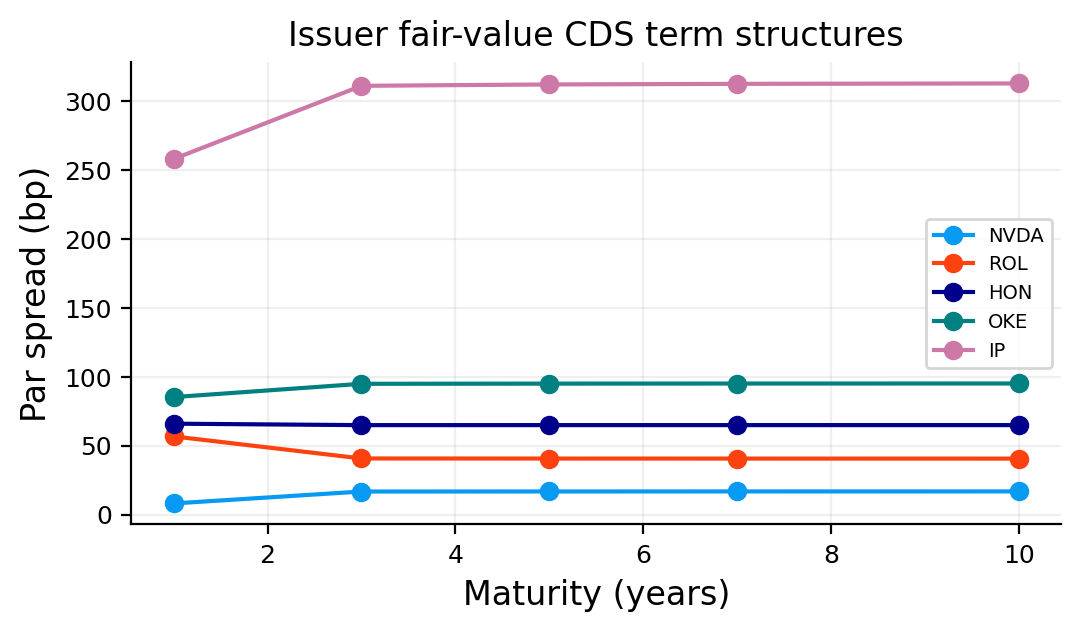

In [35]:
notional = 10_000_000.0
cds_rows = []
for i, row in issuer_hazards.reset_index(drop=True).iterrows():
    lambdas = row[lambda_q_columns].to_numpy(dtype=float)
    for T in [1, 3, 5, 7, 10]:
        premium, default = cds_legs(lambdas, pricing_knots, zero_rates, T, R=R)
        cds_rows.append({
            "cik": row["cik"], "ticker": row["ticker"], "maturity": T,
            "spread_bp": 10000 * default / premium,
            "CS01": notional * premium * 1e-4,
            "JTD": notional * LGD,
            "spread_R30_bp": 10000 * cds_par_spread(
                lambdas, pricing_knots, zero_rates, T, R=0.30),
            "spread_R50_bp": 10000 * cds_par_spread(
                lambdas, pricing_knots, zero_rates, T, R=0.50),
            "spread_hazard_150_bp": 10000 * cds_par_spread(
                1.5 * lambdas, pricing_knots, zero_rates, T, R=R)
        })
synthetic_cds = pd.DataFrame(cds_rows)

issuer_hazards["risk_decile"] = pd.qcut(
    issuer_hazards["lambda_p"].rank(method="first"), 10, labels=np.arange(1, 11))
pd_by_decile = issuer_hazards.groupby("risk_decile", observed=True).agg(
    issuers=("cik", "size"), physical_pd5=("pd5_physical", "median"),
    risk_neutral_pd5=("pd5_risk_neutral", "median"),
    relative_risk=("relative_risk", "median"))
cds5 = synthetic_cds[synthetic_cds["maturity"].eq(5)].set_index("cik")["spread_bp"]
pd_by_decile["cds5_bp"] = issuer_hazards.assign(
    cds5_bp=issuer_hazards["cik"].map(cds5)).groupby(
    "risk_decile", observed=True)["cds5_bp"].median()
pd_table = pd_by_decile.copy()
pd_table[["physical_pd5", "risk_neutral_pd5"]] *= 100
display(pd_table.rename(columns={
    "physical_pd5": "physical PD5 (%)",
    "risk_neutral_pd5": "risk-neutral PD5 (%)",
    "relative_risk": "relative physical hazard",
    "cds5_bp": "5Y CDS (bp)"
}).round(2))

representative_rows = []
for decile in [1, 3, 5, 7, 10]:
    group = issuer_hazards[issuer_hazards["risk_decile"].astype(int).eq(decile)]
    middle = group["lambda_p"].median()
    representative_rows.append(group.loc[(group["lambda_p"] - middle).abs().idxmin()])
representative = pd.DataFrame(representative_rows)
for ticker in representative["ticker"]:
    curve = synthetic_cds[synthetic_cds["ticker"].eq(ticker)]
    plt.plot(curve["maturity"], curve["spread_bp"], marker="o", label=ticker)
plt.title("Issuer fair-value CDS term structures")
plt.xlabel("Maturity (years)")
plt.ylabel("Par spread (bp)")
plt.legend()
plt.show()

In [36]:
history_start = asof_date - pd.DateOffset(years=5)
return_counts = returns.loc[history_start:asof_date].notna().sum()
issuer_hazards["return_count"] = issuer_hazards["ticker"].map(return_counts)
portfolio = issuer_hazards[issuer_hazards["return_count"].ge(756)].sort_values(
    ["E", "ticker"], ascending=[False, True]).head(125).copy()
assert len(portfolio) == 125

portfolio["notional"] = 1_000_000.0
portfolio["LGD_notional"] = LGD * portfolio["notional"]
p5 = portfolio["pd5_physical"].to_numpy()
independent_defaults = rng.random((100_000, len(portfolio))) < p5
independent_losses = independent_defaults @ portfolio["LGD_notional"].to_numpy()
portfolio_notional = portfolio["notional"].sum()
independent_rate = independent_losses / portfolio_notional
var95, es95 = hist_var_es(-independent_rate, alpha=0.05)
var99, es99 = hist_var_es(-independent_rate, alpha=0.01)

sector_weights = portfolio.groupby("sec_industry")["notional"].sum() / portfolio_notional
risk_weights = portfolio.assign(
    expected_loss=portfolio["pd5_physical"] * portfolio["LGD_notional"]).groupby(
    "sec_industry")["expected_loss"].sum()
risk_weights /= risk_weights.sum()
portfolio_summary = pd.DataFrame({"value": {
    "names": len(portfolio), "notional ($m)": portfolio_notional / 1e6,
    "5Y expected loss (%)": 100 * independent_rate.mean(),
    "5Y unexpected loss (%)": 100 * independent_rate.std(),
    "VaR 95% (%)": 100 * var95, "ES 95% (%)": 100 * es95,
    "VaR 99% (%)": 100 * var99, "ES 99% (%)": 100 * es99,
    "sector notional HHI": np.sum(sector_weights ** 2),
    "sector expected-loss HHI": np.sum(risk_weights ** 2)
}})

,expected loss (%),unexpected loss (%),VaR 95% (%),ES 95% (%),VaR 99% (%),ES 99% (%),median OAS correlation,median LW correlation
Independent,0.283,0.366,0.96,1.060,1.44,1.512,0.249,0.246
Gaussian copula,0.280,0.755,1.44,2.496,3.36,5.071,0.249,0.246
"t copula, ν=5",0.281,1.373,1.44,4.215,6.24,11.090,0.249,0.246


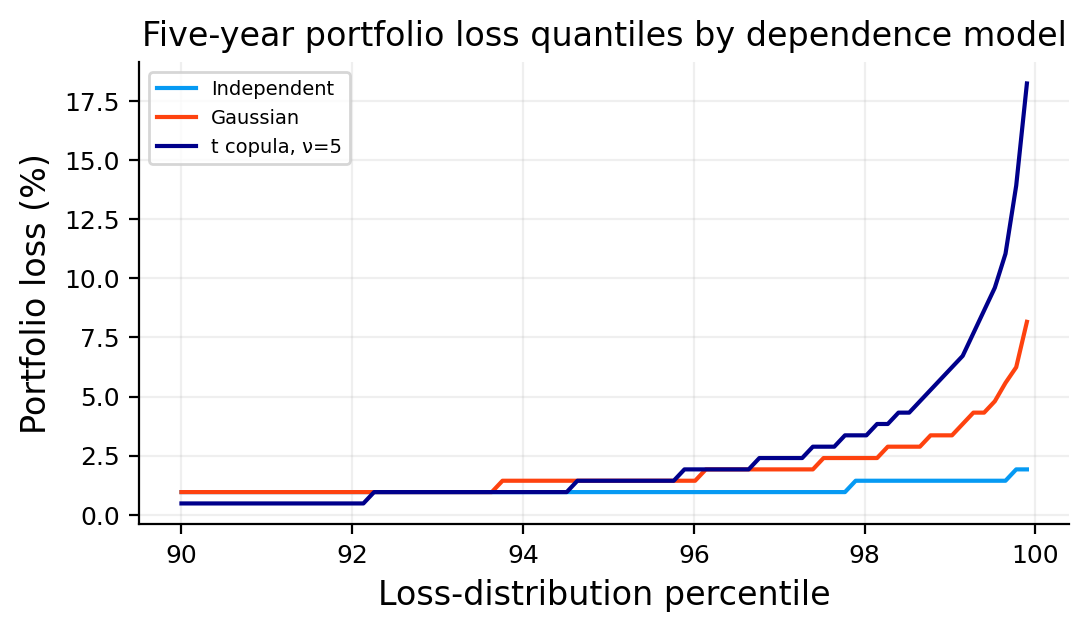

In [37]:
portfolio_tickers = portfolio["ticker"].tolist()
R_window = returns.loc[history_start:asof_date, portfolio_tickers]
cov_oas = oas_covariance(R_window, return_df=True)
cov_lw = ledoit_wolf_covariance(R_window, return_df=True)

def covariance_to_correlation(cov):
    sigma = np.sqrt(np.diag(cov))
    return pd.DataFrame(cov / np.outer(sigma, sigma), index=cov.index, columns=cov.columns)

rho_oas = covariance_to_correlation(cov_oas)
rho_lw = covariance_to_correlation(cov_lw)
portfolio = portfolio.set_index("ticker").loc[rho_oas.index]
portfolio.index.name = "ticker"
portfolio = portfolio.reset_index()
p5 = portfolio["pd5_physical"].to_numpy()
loss_given_default = portfolio["LGD_notional"].to_numpy()

def copula_uniforms(rho, simulations, family="gaussian", nu=5, seed=22):
    rho = make_psd(np.asarray(rho, dtype=float), eps=1e-8)
    scale = np.sqrt(np.diag(rho))
    rho = rho / np.outer(scale, scale)
    L = np.linalg.cholesky(rho + 1e-10 * np.eye(len(rho)))
    draw = np.random.default_rng(seed).standard_normal((simulations, len(rho))) @ L.T
    if family == "gaussian":
        return norm.cdf(draw).astype("float32")
    chi2 = np.random.default_rng(seed + 1).chisquare(nu, size=(simulations, 1))
    return student_t.cdf(draw / np.sqrt(chi2 / nu), df=nu).astype("float32")

U_gaussian = copula_uniforms(rho_oas, 60_000, family="gaussian", seed=37)
U_t = copula_uniforms(rho_oas, 60_000, family="t", nu=5, seed=37)
gaussian_losses = (U_gaussian < p5) @ loss_given_default
t_losses = (U_t < p5) @ loss_given_default

def loss_metrics(losses):
    rate = losses / portfolio["notional"].sum()
    var95, es95 = hist_var_es(-rate, alpha=0.05)
    var99, es99 = hist_var_es(-rate, alpha=0.01)
    return {
        "expected loss (%)": 100 * rate.mean(),
        "unexpected loss (%)": 100 * rate.std(),
        "VaR 95% (%)": 100 * var95, "ES 95% (%)": 100 * es95,
        "VaR 99% (%)": 100 * var99, "ES 99% (%)": 100 * es99
    }

dependence_results = pd.DataFrame({
    "Independent": loss_metrics(independent_losses),
    "Gaussian copula": loss_metrics(gaussian_losses),
    "t copula, ν=5": loss_metrics(t_losses)
}).T
dependence_results["median OAS correlation"] = np.median(
    rho_oas.to_numpy()[np.triu_indices(len(rho_oas), 1)])
dependence_results["median LW correlation"] = np.median(
    rho_lw.to_numpy()[np.triu_indices(len(rho_lw), 1)])
display(dependence_results.round(3))

percentiles = np.linspace(0.90, 0.999, 80)
for label, losses in {"Independent": independent_losses, "Gaussian": gaussian_losses,
                      "t copula, ν=5": t_losses}.items():
    plt.plot(100 * percentiles, 100 * np.quantile(losses / portfolio_notional, percentiles),
             label=label)
plt.title("Five-year portfolio loss quantiles by dependence model")
plt.xlabel("Loss-distribution percentile")
plt.ylabel("Portfolio loss (%)")
plt.legend()
plt.show()

In [38]:
tranches = [("Equity", 0.00, 0.03), ("Junior mezzanine", 0.03, 0.07),
            ("Senior mezzanine", 0.07, 0.15), ("Senior", 0.15, 0.30),
            ("Super senior", 0.30, 1.00)]

def tranche_loss(portfolio_loss, A, D):
    return np.clip((portfolio_loss - A) / (D - A), 0.0, 1.0)

tranche_rows = []
portfolio_hazards = portfolio.set_index("ticker")
for year in range(1, 6):
    p = np.array([
        1 - survival_probability(
            year, pricing_knots, row[lambda_p_columns].to_numpy(dtype=float))[0]
        for _, row in portfolio_hazards.iterrows()
    ])
    loss = ((U_t < p) @ loss_given_default) / portfolio_notional
    for name, A, D in tranches:
        layer_loss = tranche_loss(loss, A, D)
        tranche_rows.append({
            "year": year, "tranche": name, "attachment": A, "detachment": D,
            "expected_loss": layer_loss.mean(),
            "impairment_probability": np.mean(loss > A),
            "expected_outstanding": 1.0 - layer_loss.mean()
        })
tranche_results = pd.DataFrame(tranche_rows)
five_year_tranches = tranche_results[tranche_results["year"].eq(5)].set_index("tranche")
display((100 * five_year_tranches[
    ["attachment", "detachment", "expected_loss", "impairment_probability",
     "expected_outstanding"]]).round(2))

,attachment,detachment,expected_loss,impairment_probability,expected_outstanding
tranche,,,,,
Equity,0.0,3.0,6.08,13.99,93.92
Junior mezzanine,3.0,7.0,1.39,2.31,98.61
Senior mezzanine,7.0,15.0,0.41,0.82,99.59
Senior,15.0,30.0,0.07,0.18,99.93
Super senior,30.0,100.0,0.00,0.01,100.00


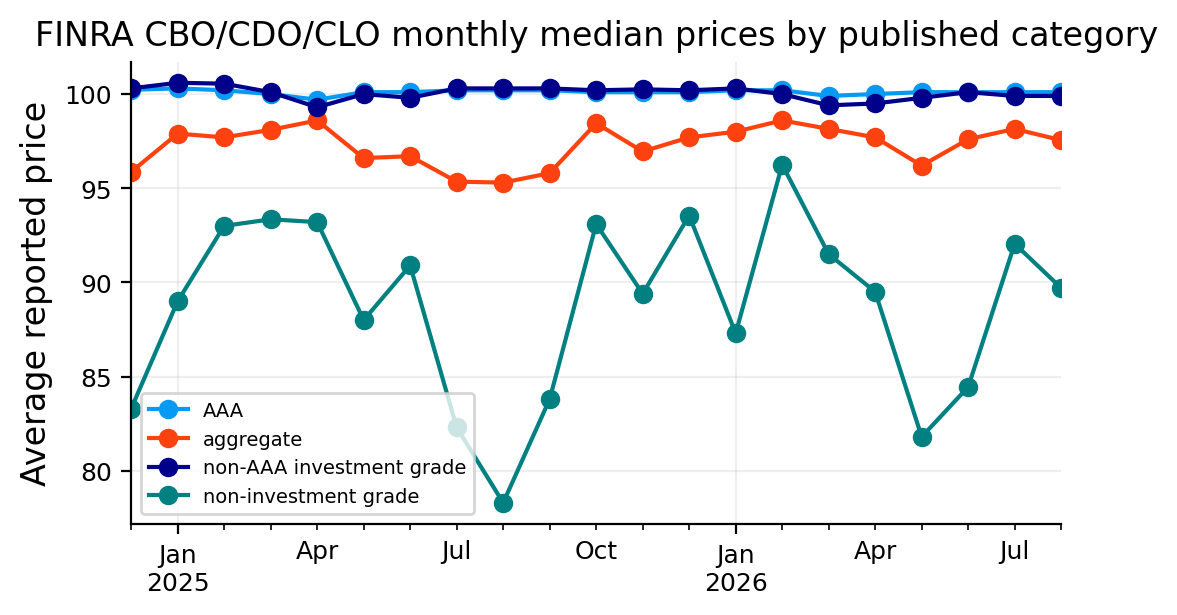

,observations,mean_price,minimum_price,latest_price
category,,,,
AAA,833,100.06,97.00,100.1
non-AAA investment grade,800,99.92,94.20,100.3
aggregate,1255,96.59,59.57,105.7
non-investment grade,750,86.71,11.20,132.3


In [39]:
structured = con.execute(f"""
    SELECT report_date, sheet, table_title, rating_group, metric_group,
           row_label, column_label, value, value_status
    FROM read_parquet('{STRUCTURED_PRICE_PATH.as_posix()}')
    WHERE sheet = 'CBO-CDO-CLO' AND report_date >= DATE '2024-12-09'
""").fetchdf()
structured_activity = con.execute(f"""
    SELECT report_date, row_label, column_label, value, value_status
    FROM read_parquet('{STRUCTURED_ACTIVITY_PATH.as_posix()}')
    WHERE row_label = 'CBO/CDO/CLO'
""").fetchdf()
errata = pd.read_parquet(ERRATA_PATH)
relevant_errata = errata[
    errata["sub_asset_class"].str.contains("CBO/CDO/CLO", case=False, na=False)
    & errata["trade_date"].ge(pd.Timestamp("2024-12-09"))]
assert relevant_errata.empty

text = (structured["rating_group"].fillna("") + " | "
        + structured["column_label"].fillna("")).str.upper()
category = pd.Series("aggregate", index=structured.index, dtype="string")
category[text.str.contains("NON-INVESTMENT GRADE")] = "non-investment grade"
category[text.str.contains("NON-AAA IG")] = "non-AAA investment grade"
category[text.str.contains("AAA") & ~text.str.contains("NON-AAA")] = "AAA"
structured["category"] = category
structured["vintage"] = pd.Series("aggregate", index=structured.index, dtype="string")
structured.loc[text.str.contains("PRE-2022"), "vintage"] = "pre-2022"
structured.loc[text.str.contains("2022-2025"), "vintage"] = "2022-2025"
structured.loc[text.str.contains("PRE-2023"), "vintage"] = "pre-2023"
structured.loc[text.str.contains("2023-2026"), "vintage"] = "2023-2026"
structured["metric"] = structured["row_label"].where(
    structured["row_label"].str.len().gt(0), structured["metric_group"]).str.upper()

prices = structured[
    structured["metric"].eq("AVERAGE PRICE") & structured["value"].gt(0)].groupby(
    ["report_date", "category", "vintage"], as_index=False)["value"].mean()
prices["decision_date"] = pd.to_datetime(prices["report_date"]).dt.to_period("M").dt.to_timestamp("M")
prices = prices.sort_values("report_date")
price_history = prices.groupby(["decision_date", "category"])["value"].median().unstack()

activity_text = structured_activity["column_label"].str.upper()
structured_activity["grade"] = "investment grade"
structured_activity.loc[
    activity_text.str.contains("NON-INVESTMENT"), "grade"] = "non-investment grade"
structured_activity["metric"] = "other"
structured_activity.loc[activity_text.str.contains("\$ TRADES"), "metric"] = "volume"
structured_activity.loc[activity_text.str.contains("TRADE \| COUNT"), "metric"] = "trades"
structured_activity["decision_date"] = pd.to_datetime(
    structured_activity["report_date"]).dt.to_period("M").dt.to_timestamp("M")
activity_history = structured_activity[
    structured_activity["metric"].isin(["volume", "trades"])
    & structured_activity["value"].notna()].groupby(
    ["decision_date", "grade", "metric"])["value"].sum().unstack(["grade", "metric"])

price_history.plot(marker="o")
plt.title("FINRA CBO/CDO/CLO monthly median prices by published category")
plt.ylabel("Average reported price")
plt.xlabel("")
plt.legend()
plt.show()

category_summary = prices.groupby("category").agg(
    observations=("value", "size"), mean_price=("value", "mean"),
    minimum_price=("value", "min"), latest_price=("value", "last")).sort_values(
    "mean_price", ascending=False)
vintage_summary = prices[prices["vintage"].ne("aggregate")].groupby(
    ["category", "vintage"])["value"].agg(["count", "mean", "min", "last"])
display(category_summary.round(2))

In [40]:
dependence_states = [
    {"state": "Gaussian, 0.75ρ", "family": "gaussian", "nu": 0, "rho_scale": 0.75},
    {"state": "Gaussian, ρ", "family": "gaussian", "nu": 0, "rho_scale": 1.00},
    {"state": "t(7), ρ", "family": "t", "nu": 7, "rho_scale": 1.00},
    {"state": "t(4), 1.25ρ", "family": "t", "nu": 4, "rho_scale": 1.25}
]
uniforms = {}
rho = rho_oas.to_numpy()
for i, state in enumerate(dependence_states):
    rho_state = np.eye(len(rho)) + state["rho_scale"] * (rho - np.eye(len(rho)))
    uniforms[state["state"]] = copula_uniforms(
        rho_state, 20_000, family=state["family"], nu=state["nu"] or 5, seed=220 + i)

latest_spread = hqm_spread.loc[:asof_date, 5].dropna().iloc[-1]
historical_scenarios = {
    "Half PD": 0.5,
    "Base": 1.0,
    "Double PD": 2.0,
    "Triple PD": 3.0,
    "November 2008 spread ratio": hqm_spread.loc[stress_dates[0], 5] / latest_spread,
    "March 2020 spread ratio": hqm_spread.loc[stress_dates[1], 5] / latest_spread
}
stress_rows = []
weights = portfolio["notional"].to_numpy() / portfolio_notional
for scenario, multiplier in historical_scenarios.items():
    p = 1.0 - (1.0 - p5) ** multiplier
    for recovery in [0.20, 0.40, 0.60]:
        for state in dependence_states:
            loss = (uniforms[state["state"]] < p) @ weights * (1.0 - recovery)
            var99, es99 = hist_var_es(-loss, alpha=0.01)
            stress_rows.append({
                "scenario": scenario, "PD multiplier": multiplier, "recovery": recovery,
                "dependence": state["state"], "expected loss (%)": 100 * loss.mean(),
                "VaR 99% (%)": 100 * var99, "ES 99% (%)": 100 * es99,
                "equity EL (%)": 100 * tranche_loss(loss, 0.00, 0.03).mean(),
                "mezzanine EL (%)": 100 * tranche_loss(loss, 0.03, 0.07).mean(),
                "senior EL (%)": 100 * tranche_loss(loss, 0.15, 0.30).mean()
            })
stress_results = pd.DataFrame(stress_rows)

final_summary = pd.DataFrame({"value": {
    "ensemble OOS ROC-AUC": discrimination.loc["Final multi-horizon ensemble", "ROC-AUC"],
    "ensemble OOS PR-AUC": discrimination.loc["Final multi-horizon ensemble", "PR-AUC"],
    "24m ensemble ROC-AUC": horizon_results.query(
        "horizon == 24 and model == 'Direct multi-horizon ensemble'")["ROC-AUC"].iloc[0],
    "L2 premium / EBP correlation": premium_validation.loc["Accounting L2", "correlation"],
    "market price of credit risk kappa": kappa,
    "portfolio 5Y expected loss (%)": dependence_results.loc[
        "t copula, ν=5", "expected loss (%)"],
    "portfolio 5Y ES 99% (%)": dependence_results.loc["t copula, ν=5", "ES 99% (%)"],
    "equity tranche 5Y EL (%)": 100 * five_year_tranches.loc["Equity", "expected_loss"],
    "senior tranche 5Y EL (%)": 100 * five_year_tranches.loc["Senior", "expected_loss"],
    "FINRA structured categories": len(category_summary),
    "current valuation month": asof_date
}})

current_snapshot = issuer_hazards.merge(
    synthetic_cds[synthetic_cds["maturity"].eq(5)], on="cik", how="left")
current_snapshot.to_parquet(cache / f"current_credit_snapshot_{run_hash}.parquet", index=False)
stress_results.to_parquet(cache / f"joint_stress_{run_hash}.parquet", index=False)
(cache / f"run_config_{run_hash}.json").write_text(
    json.dumps(config, indent=2, default=str), encoding="utf-8")
display(final_summary.round(4))
display(stress_results.sort_values("ES 99% (%)", ascending=False).head(12).round(2))

,value
ensemble OOS ROC-AUC,0.895433
ensemble OOS PR-AUC,0.099557
24m ensemble ROC-AUC,0.867025
L2 premium / EBP correlation,0.791544
market price of credit risk kappa,13.13648
portfolio 5Y expected loss (%),0.281256
portfolio 5Y ES 99% (%),11.089789
equity tranche 5Y EL (%),6.076867
senior tranche 5Y EL (%),0.066693
FINRA structured categories,4


,scenario,PD multiplier,recovery,dependence,expected loss (%),VaR 99% (%),ES 99% (%),equity EL (%),mezzanine EL (%),senior EL (%)
51,November 2008 spread ratio,10.80,0.2,"t(4), 1.25ρ",3.93,36.48,45.12,47.79,22.81,3.70
50,November 2008 spread ratio,10.80,0.2,"t(7), ρ",3.81,28.16,36.09,54.96,24.37,2.34
55,November 2008 spread ratio,10.80,0.4,"t(4), 1.25ρ",2.95,27.36,33.84,43.04,18.02,2.01
63,March 2020 spread ratio,3.41,0.2,"t(4), 1.25ρ",1.28,21.12,30.55,18.69,6.99,1.00
39,Triple PD,3.00,0.2,"t(4), 1.25ρ",1.13,19.84,29.45,16.74,6.13,0.86
49,November 2008 spread ratio,10.80,0.2,"Gaussian, ρ",3.90,22.40,27.80,63.10,27.10,1.33
54,November 2008 spread ratio,10.80,0.4,"t(7), ρ",2.86,21.12,27.07,49.26,18.25,1.03
27,Double PD,2.00,0.2,"t(4), 1.25ρ",0.76,15.36,24.46,11.69,4.12,0.54
67,March 2020 spread ratio,3.41,0.4,"t(4), 1.25ρ",0.96,15.84,22.91,16.32,5.36,0.50
59,November 2008 spread ratio,10.80,0.6,"t(4), 1.25ρ",1.97,18.24,22.56,36.12,12.08,0.57
